<a href="https://colab.research.google.com/github/lapidesd/deficit_aggregation/blob/main/Code/deficit_averaging_data_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
! pip install geopandas
import geopandas as gpd
import time
import numpy as np
%config InlineBackend.figure_format = 'retina'
%matplotlib inline
from matplotlib import gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
matplotlib.rcParams.update(matplotlib.rcParamsDefault)
! pip install hydrofunctions
import hydrofunctions as hf
import geemap
import joblib
import datetime

import requests
import pickle
import matplotlib.font_manager as fm
!wget https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf
plt.rcParams.update({'font.size': 12})
from shapely.geometry import Polygon
%matplotlib inline
!pip install dataretrieval
import dataretrieval.nwis as nwis
import warnings
from matplotlib.gridspec import GridSpec
import matplotlib.dates as mdates



warnings.filterwarnings("ignore")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 32.4 MB/s eta 0:00:00
--2025-09-11 20:02:59--  https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/Phonbopit/sarabun-webfont/master/fonts/thsarabunnew-webfont.ttf [following]
--2025-09-11 20:02:59--  https://raw.githubusercontent.com/Phonbopit/sarabun-webfont/master/fonts/thsarabunnew-webfont.ttf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 98308 (96K) [application/octet-stream]
S

## Earth Engine authenticate and initialize

In [2]:
import ee
ee.Authenticate()
ee.Initialize(project='15647375014')

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_7TDKVSyKvBdmMqW?ref=4i2o6


## Import information about study sites

In [3]:
# import shapefile of study sites and site info
loc = 'https://raw.github.com/lapidesd/deficit_aggregation/main/Data/deficit_agg_sites.zip'
gages = gpd.read_file(loc).set_crs('EPSG:4269').to_crs(epsg = 4326)
gage_info = gages
# US state map from https://catalog.data.gov/dataset/tiger-line-shapefile-2017-nation-u-s-current-state-and-equivalent-national
loc = 'https://raw.githubusercontent.com/lapidesd/CA_missing_freshet/main/Data/state_outline.zip'
state_outline = gpd.read_file(loc).to_crs(epsg = 4326)
state_outline = state_outline[state_outline.STUSPS.isin(['CA'])]

In [4]:



casites = gpd.read_file('https://raw.github.com/lapidesd/CA_missing_freshet/main/Data/california_site_list.zip').rename(columns={'SITE_NO':'STAID',
                                                                                                               'STATION_NM':'STANAME',})
cabasins = gpd.read_file('https://raw.github.com/lapidesd/CA_missing_freshet/main/Data/california_site_watershed_boundaries.zip').rename(columns={'SITE_NO':'STAID',})
casites = casites.drop(columns=['geometry',]).merge(cabasins.drop(columns='ABS_DIFF'),on='STAID')
casites['DRAIN_SQKM'] = casites.SQMI*2.58999
casites = casites.drop(columns=['LON_SITE','LAT_SITE','SQMI'])
casites = gpd.GeoDataFrame(casites, geometry = casites.geometry).to_crs(epsg = 4326)
casites
gage_info = gages = casites

In [5]:
loc = 'https://raw.github.com/lapidesd/deficit_aggregation/main/Data/B120Basins_w_FNF_area_plus.zip'
gages = gpd.read_file(loc).to_crs(epsg = 4326)
gage_info = gages
gages = gages.rename(columns={'STATION':'STANAME',
                      'ID':'STAID'})

In [8]:
data1 = {}
for key in gage_info.ID.values:
  print(key)
  try:
    d = pd.read_csv('https://raw.github.com/lapidesd/deficit_aggregation/main/Data/SWANN/'+str(key)+'_data_SWANN.csv')
    d['Unnamed: 0'] = pd.to_datetime(d['Unnamed: 0'])
    d = d.set_index('Unnamed: 0')
    data1[key] = d
  except:
    continue

AMF
MSS
SDT
TNL
PSH
YRS
TKT
WFC
CSN
EFC
MKM
WWR
EWR
SNS
TLG
MRC
SBF
KGF
KWT
SCC
KRI
FTO
SIS
SBB
TRF


In [10]:
cageo = ee.Geometry.Polygon(list(state_outline.geometry.values[0].geoms[12].exterior.coords))

In [11]:
# convert geopandas basin objects into geojson for Earth Engine
scale = 4000
geos1 = gage_info.geometry.values
geos = []
for i in range(len(geos1)):
  try:
    geo_obj = ee.Geometry.Polygon(list(geos1[i].exterior.coords))
  except:
    # geos1[i] = geos1[i][-1]
    geos1[i] = (geos1[i].geoms[-1])
    geo_obj = ee.Geometry.Polygon(list(geos1[i].exterior.coords))
  geos.append(geo_obj)
names = gages.STAID.values

ystart_all = 2000
ystop_all = 2023
start_all=str(ystart_all)+'-10-01'
stop_all=str(ystop_all)+'-11-01'#'2021-10-01'

# Make SWANN SWE asset

In [ ]:
uriBase = 'danalapides/swann_swe/'
assetList = ee.data.getList({'id':f'users/{uriBase}'})
import datetime

def extract_date_from_filename(asset_id):
    # Example: 'users/danalapides/snow/snow_20240101'
    basename = asset_id.split('/')[-1]
    date_str = basename.replace('_','')[-8:]  # assumes 'YYYYMMDD' at end
    return datetime.datetime.strptime(date_str, '%Y%m%d')

def build_image_with_time(asset_id):
    date_str = asset_id.split('/')[-1].replace('_','')[-8:]  # '20240101'
    image = ee.Image(asset_id).set('system:time_start', ee.Date.parse('YYYYMMdd', date_str).millis())
    image = image.set('system:index', date_str)  #
    # date = extract_date_from_filename(asset_id)
    # millis = int(date.timestamp() * 1000)
    return image#ee.Image(asset_id).set('system:time_start', millis)

# assetList from earlier
image_ids = [item['id'] for item in assetList if item['type'] == 'Image']

# Convert to ImageCollection with timestamps
images = [build_image_with_time(id).rename('SWE') for id in image_ids]
SWANN_SWE = ee.ImageCollection(images)
def set_index_to_date(img):
    date_str = ee.Date(img.get('system:time_start')).format('YYYYMMdd')
    return img.set('system:index', date_str)

SWANN_SWE = SWANN_SWE.map(set_index_to_date)

# Print first image metadata
print(SWANN_SWE.first().reduceRegion(ee.Reducer.mean(), geos[0], scale, maxPixels = 673307936989480).getInfo())

{'SWE': 0.9754391542802635}


#Download and compute pixel-scale data in GEE

## Get SWE data from SWANN SWE via Earth Engine

In [ ]:
def interpolate_swe(dataset, max_gap_days=7):
    # Ensure images are sorted by time
    dataset = dataset.sort('system:time_start')
    img_list = dataset.toList(dataset.size())

    def interp_or_zero(i):
        i = ee.Number(i)
        current = ee.Image(img_list.get(i))
        prev = ee.Image(img_list.get(i.subtract(1)))

        # Get the time difference
        curr_time = ee.Date(current.get('system:time_start'))
        prev_time = ee.Date(prev.get('system:time_start'))
        diff_days = curr_time.difference(prev_time, 'day')

        # Linear interpolate if diff ≤ max_gap_days
        def interpolate():
            def day_offset(n):
                n = ee.Number(n)
                alpha = n.divide(diff_days)  # interpolation weight
                interp_img = prev.multiply(ee.Image.constant(1).subtract(alpha)).add(current.multiply(alpha))
                date = prev_time.advance(n, 'day')
                return interp_img.set('system:time_start', date.millis())

            # List of days to interpolate (excluding endpoints)
            days = ee.List.sequence(1, diff_days.subtract(1))
            return days.map(day_offset)

        # Fill with zero images if gap > max_gap_days
        def zero_fill():
            def make_zero(n):
                date = prev_time.advance(n, 'day')
                zeros = prev.multiply(1)
                return zeros.set('system:time_start', date.millis())
            days = ee.List.sequence(1, diff_days.subtract(1))
            return days.map(make_zero)

        interp = ee.Algorithms.If(diff_days.lte(max_gap_days), interpolate(), zero_fill())
        return interp

    # Loop over all image pairs to generate interpolated collections
    interp_lists = ee.List.sequence(1, dataset.size().subtract(1)).map(interp_or_zero)

    # Flatten interpolated image lists
    interp_flat = ee.ImageCollection(interp_lists.flatten())

    # Combine original + interpolated, sort
    return dataset.merge(interp_flat).sort('system:time_start')

In [ ]:
# add year-month property to each image
def add_ym (image):
  date = ee.Date(image.get('system:time_start'))
  ym = date.format('YYYY-MM')
  return image.set('year_month',ym)



def get_swe(geo, start , stop ):


    dataset = SWANN_SWE


    # Compute daily SWE differences
    def diff_days(col):
        img_list = col.toList(col.size())

        def compute_diff(i):
            i = ee.Number(i)
            current = ee.Image(img_list.get(i))
            prev = ee.Image(img_list.get(i.subtract(1)))
            delta = current.subtract(prev).copyProperties(current, current.propertyNames())
            return delta.set('system:time_start', current.get('system:time_start'))

        indices = ee.List.sequence(1, col.size().subtract(1))
        return ee.ImageCollection(indices.map(compute_diff))

    swepixel = diff_days(dataset)

    diffed = swepixel.map(add_ym)

    def monthly_sum(grouped):
        months = diffed.aggregate_array('year_month').distinct()

        def make_monthly(ym):
            ym = ee.String(ym)
            monthly_images = diffed.filter(ee.Filter.eq('year_month', ym))
            summed = monthly_images.sum()
            date = ee.Date.parse('YYYY-MM', ym)
            return summed.set({
                'system:time_start': date.millis(),
                'year_month': ym
            })

        return ee.ImageCollection(months.map(make_monthly))

    swepixel = monthly_sum(diffed)
    return swepixel

## Get ET data from Earth Engine

In [ ]:
def get_et(geo, start , stop ):
  # code adapted from David Dralle
  # Flux is stored as 100*mm/day, and duration between samples is 8 days
  multiplier = 8.0
  dataset = ee.ImageCollection("CAS/IGSNRR/PML/V2_v018").filterBounds(geo).filterDate(start,stop)

  # mapper for getting single ET raster for each timestep
  def sumpml(image, ):
    # ET bands into one band
    temp = image.select('Es').add(image.select('Ec')).add(image.select('Ei'))#.multiply(scale)

    #get the first band of this new temporary image, rename it to 'ET',
    #reproject it, and then multiply by multiplier
    temp = temp.select([0], ['ET']).reproject(
        crs='EPSG:4326',scale=scale
        ).multiply(multiplier)#.multiply(scale)

    #temp should now be total ET in mm over the time window between images
    #assign the datetime stamp and the index from the original image
    temp = temp.set('system:time_start', image.get('system:time_start'))
    temp = temp.set('system:index', image.get('system:index'))
    return temp

  #now, actually map the pml image collection w/ this function,
  # in order to make a new combined ET image collection
  etpixel = ee.ImageCollection(dataset.map(sumpml).select('ET')).filter(ee.Filter.date(start, stop))
  # et = etpixel.toBands()

  diffed = etpixel.map(add_ym)

  # group by year-month and reduce with sum
  def monthly_sum(grouped):
    months = diffed.aggregate_array('year_month').distinct()

    def make_monthly(ym):
      ym = ee.String(ym)
      monthly_images = diffed.filter(ee.Filter.eq('year_month', ym))
      summed = monthly_images.sum()
      date = ee.Date.parse('YYYY-MM', ym)
      return summed.set({'system:time_start':date.millis(),
                         'year_month':ee.String(ym)})

    return ee.ImageCollection(months.map(make_monthly))

  etpixel = monthly_sum(diffed)

  return etpixel

## Get P data from Earth Engine and combine with SWE data

In [ ]:
def get_p(geo, swepixel, start , stop ):
    # Monthly PRISM precipitation
    Ppixel = ee.ImageCollection("OREGONSTATE/PRISM/AN81m") \
        .filterBounds(geo) \
        .filterDate(start, stop) \
        .select('ppt')

    # Add year-month label
    diffed = Ppixel.map(add_ym)

    # Monthly sum of precipitation
    def monthly_sum(grouped):
        months = diffed.aggregate_array('year_month').distinct()

        def make_monthly(ym):
            ym = ee.String(ym)
            monthly_images = diffed.filter(ee.Filter.eq('year_month', ym))
            summed = monthly_images.sum()
            date = ee.Date.parse('YYYY-MM', ym)
            return summed.set({
                'system:time_start': date.millis(),
                'year_month': ym
            })

        return ee.ImageCollection(months.map(make_monthly))

    P_monthly = monthly_sum(diffed)
    SWE_monthly = swepixel

    # Do a temporal join on system:time_start
    filter_time_eq = ee.Filter.equals(leftField='system:time_start', rightField='system:time_start')
    inner_join = ee.Join.saveFirst(matchKey='matched')

    joined = inner_join.apply(P_monthly, SWE_monthly, filter_time_eq)


    joined = ee.FeatureCollection(joined)

    # Subtract ppt - swe
    def subtract_matched(feature):
      ppt = ee.Image(feature)
      ppt_band = ppt.select('ppt')

      matched = feature.get('matched')  # This is a server-side object (may be null)

      def has_match():
          swe = ee.Image(matched)  # Now safe: only called if matched is not null
          swe_band = swe.select('swe')
          swe_capped = swe_band.where(swe_band.gt(ppt_band),ppt_band,)

          return ppt_band.rename('ppt_minus_swe')

      def no_match():
          return ppt_band.rename('ppt_minus_swe')

      result = ee.Image(ee.Algorithms.If(matched, has_match(), no_match()))
      # result = ee.Algorithms.If(result.select('ppt_minus_swe').lt(-100),0,result.select('ppt_minus_swe'))
      return result.set('system:time_start', ppt.get('system:time_start'))

    result = ee.ImageCollection(joined.map(subtract_matched))
    return result


## Calculate deficit at pixel scale for each basin

In [ ]:

def compute_deficit(img_list, first_bool, prev_image,
                    start , stop , init_deficit=0, ):
    def loop_fn(i, prev):
        i = ee.Number(i)
        current = ee.Image(img_list.get(i))
        prevD = ee.Image(prev)

        P = current.select('ppt_minus_swe')
        ET = current.select('ET')

        diff = P.subtract(ET)  # P - ET
        delta = ET.subtract(P)  # ET - P

        # Initialize new D as previous D + delta
        newD = prevD.add(delta)

        # Where (P - ET) >= D, reset D to 0
        newD = newD.where(newD.lte(0), 0)

        newD = newD.rename('D')
        newD = newD.set('system:time_start', current.get('system:time_start'))

        return newD

    # Initialize with first timestep
    first = ee.Image(img_list.get(0))
    P1 = first.select('ppt_minus_swe')
    ET1 = first.select('ET')

    diff1 = P1.subtract(ET1)  # P - ET
    delta1 = ET1.subtract(P1)  # ET - P

    # Start with deficit = 0 everywhere
    if first_bool:
      firstD = ee.Image(init_deficit).rename('D')
    else:
      firstD = prev_image

    firstD = firstD.set('system:time_start', first.get('system:time_start'))

    result_list = ee.List([firstD])

    def wrapper(i, acc):
        prev = ee.Image(ee.List(acc).get(-1))
        currentD = loop_fn(i, prev)
        return ee.List(acc).add(currentD)

    indices = ee.List.sequence(0, img_list.size().subtract(1))
    final_list = indices.iterate(wrapper, result_list)

    return ee.ImageCollection(ee.List(final_list))

In [ ]:

def compute_Q(img_list, first_bool, prev_image,
                    start , stop , init_deficit=0, ):
    def loop_fn(i, prev):
        i = ee.Number(i)
        current = ee.Image(img_list.get(i))
        prevD = ee.Image(prev)

        P = current.select('ppt_minus_swe')
        ET = current.select('ET')

        diff = P.subtract(ET)  # P - ET
        delta = ET.subtract(P)  # ET - P

        # Initialize new D as previous D + delta
        newD = prevD.add(delta)

        # Where (P - ET) >= D, reset D to 0
        newQ = newD.multiply(-1)
        newQ = newQ.where(newQ.lte(0),0)
        newD = newD.where(newD.lte(0), 0)

        newQ = newQ.rename('Q')
        newD = newD.rename('D')
        newQ = newQ.set('system:time_start', current.get('system:time_start'))
        newD = newD.set('system:time_start', current.get('system:time_start'))

        return newD#, newQ
    def loop_fnQ(i, prev):
        i = ee.Number(i)
        current = ee.Image(img_list.get(i))
        prevD = ee.Image(prev)

        P = current.select('ppt_minus_swe')
        ET = current.select('ET')

        diff = P.subtract(ET)  # P - ET
        delta = ET.subtract(P)  # ET - P

        # Initialize new D as previous D + delta
        newD = prevD.add(delta)

        # Where (P - ET) >= D, reset D to 0
        newQ = newD.multiply(-1).where(newD.gte(0),0)
        # newQ = newQ.max(0)
        # newD = newD.where(newD.lte(0), 0)

        newQ = newQ.rename('Q')
        # newD = newD.rename('D')
        newQ = newQ.set('system:time_start', current.get('system:time_start'))
        # newD = newD.set('system:time_start', current.get('system:time_start'))

        return newQ#, newQ

    # Initialize with first timestep
    first = ee.Image(img_list.get(0))
    P1 = first.select('ppt_minus_swe')
    ET1 = first.select('ET')

    diff1 = P1.subtract(ET1)  # P - ET
    delta1 = ET1.subtract(P1)  # ET - P

    # Start with deficit = 0 everywhere
    if first_bool:
      firstD = ee.Image(init_deficit).rename('D')
    else:
      firstD = prev_image

    firstD = firstD.set('system:time_start', first.get('system:time_start'))

    result_list = ee.List([firstD])
    Q_list = ee.List([])

    def wrapper(i, acc):
        prev = ee.Image(ee.List(acc).get(-1))
        currentD = loop_fn(i, prev)
        return ee.List(acc).add(currentD)





    indices = ee.List.sequence(0, img_list.size().subtract(1))
    final_list = indices.iterate(wrapper, result_list)

    def wrapper1(i, acc):
        prev = ee.Image(ee.List(final_list).get(i))
        currQ = loop_fnQ(i,prev)
        return ee.List(acc).add(currQ)

    Q_list = indices.iterate(wrapper1, Q_list)

    return ee.ImageCollection(ee.List(Q_list))

In [ ]:
def export_task_fun(imageCollection, name, ystart ,
                ystop, geo, m='10', scale = scale):
  # export annual deficit image for october 1


  for y in range(ystart+1,ystop):
    # print('doing something?')
    if name=='Doct':
      # Define your target month
      st = ee.Date(str(y)+'-'+m+'-01')
      end = ee.Date(str(y)+'-'+m+'-03')
      # Filter D_collection to October 2020
      im = imageCollection.filterDate(st, end).first()
      file_name = str(gage_info.STAID.values[i])+'_'+name+'_'+str(y)+'_'+m
    elif name=='Q':
      # Define your target month
      st = ee.Date(str(y)+'-'+m+'-01')
      end = ee.Date(str(y+1)+'-'+str(int(m)+1)+'-1')
      if m=='12':
        end = ee.Date(str(y+1)+'-'+str(int(m))+'-31')
      # Filter D_collection to October 2020
      im = imageCollection.filterDate(st, end).reduce(ee.Reducer.sum())
      file_name = str(gage_info.STAID.values[i])+'_'+name+'_'+str(y)+'_'+m
    elif name in ['P','ET']:
      st = ee.Date(str(y)+'-'+m+'-01')
      end = ee.Date(str(y+1)+'-'+str(int(m)+1)+'-1')
      if m=='12':
        end = ee.Date(str(y+1)+'-'+str(int(m))+'-31')
      im = imageCollection.filterDate(st, end).reduce(ee.Reducer.sum())
      file_name = str(gage_info.STAID.values[i])+'_'+name+'_'+str(y)+'_'+m
    elif name in ['P_wy','ET_wy']:
      st = ee.Date(str(y)+'-10-01')
      end = ee.Date(str(y+1)+'-9-30')
      im = imageCollection.filterDate(st, end).reduce(ee.Reducer.sum())
      file_name = str(gage_info.STAID.values[i])+'_'+name+str(y+1)

    try:
      ee.data.deleteAsset('projects/ee-danalapides/assets/'+file_name)
    except:
      print('making asset for first time')

  return

def wait_for_task(task):
    while task.status()['state'] in ['READY', 'RUNNING']:
        print(f"Task {task.id} is {task.status()['state']}")
        time.sleep(15)  # wait 15 sec before checking again
    print(f"Task {task.id} finished with state: {task.status()['state']}")
    return

In [ ]:
# run the exports all combined as just 4 assets


Qarrays = []
dates = []

geo = cageo

for i in range(4):
  start = str(2000+i*6)
  stop = str(2000+(i+1)*6+1)
  # get pixel-wise swe, monthly
  swepixel = get_swe(geo, start = str(start)+'-10-01',
                    stop = str(stop)+'-10-01')
  etpixel = get_et(geo, start = str(start)+'-10-01',
                  stop = str(stop)+'-10-01')
  Ppixel = get_p(geo,swepixel, start = str(start)+'-10-01',
                stop = str(stop)+'-10-01')


  def wrap(img):
    return ee.Feature(None, {
        'system:time_start': img.get('system:time_start'),
        'year_month': img.get('year_month'),
        'image': img
    })

  P_features = Ppixel.map(wrap)
  ET_features = etpixel.map(wrap)


  filter_time_eq = ee.Filter.equals(leftField='system:index', rightField='system:index')

  inner_join = ee.Join.saveFirst(matchKey='matched')

  joined = inner_join.apply(P_features, ET_features, filter_time_eq)
  joined = ee.FeatureCollection(joined).filter(ee.Filter.notNull(['matched']))


  def combine_p_et(feature):
    ppt_metadata = feature.get('image')
    matched_feature = ee.Feature(feature.get('matched'))
    et_metadata = matched_feature.get('image')

    ppt = ee.Image(ppt_metadata)
    et = ee.Image(et_metadata)

    return ppt.addBands(et.select('ET')).set('system:time_start', ppt.get('system:time_start'))

  result = ee.ImageCollection(joined.map(combine_p_et, dropNulls=True))

  image_list = result.toList(result.size())

  if start == str(ystart_all):
    first = True
    prev_im = None
  else:
    first = False
    # print (i)
    prev_im = ee.Image('projects/ee-danalapides/assets/D_SWANN'+str(i)).select('D_'+str(2000+i*6)+'1001').rename('D')

  D_collection = compute_deficit(image_list, first, prev_image = prev_im,
                                start = start, stop = stop)
  Q_collection = compute_Q(image_list, first, prev_image = prev_im,
                                start = start, stop = stop)

  def export_stack(collection,name,st,end):
    collection = collection.filterDate(st, end)
    collection = ee.ImageCollection(collection.toList(collection.size()).slice(1))
    times = collection.aggregate_array('system:time_start').getInfo()
    times = [''.join(str(datetime.datetime.fromtimestamp(t/1000)).split()[0].split('-')) for t in times]
    stack = collection.toBands()
    bands = stack.bandNames()
    stack = stack.select(bands,['D_'+t for t in times])#.bandNames()

    file_name = name
    try:
        ee.data.deleteAsset('projects/ee-danalapides/assets/'+file_name)
    except:
        print('making asset for first time')
    export_task = ee.batch.Export.image.toAsset(
        image=stack,
        description = file_name,
        assetId='projects/ee-danalapides/assets/'+file_name,
        scale = scale,
        region=geo,
        maxPixels=1e13
    )
    export_task.start()
    return export_task


  # t = export_stack(D_collection,'D_SWANN'+str(i+1),start,stop)
  # wait_for_task(t)
  t = export_stack(Q_collection,'Q_SWANN'+str(i+1),start,stop)
  wait_for_task(t)


making asset for first time
Task E7D6WMJHUE4OG4U6FJYGESDO is READY
Task E7D6WMJHUE4OG4U6FJYGESDO is RUNNING
Task E7D6WMJHUE4OG4U6FJYGESDO is RUNNING
Task E7D6WMJHUE4OG4U6FJYGESDO is RUNNING
Task E7D6WMJHUE4OG4U6FJYGESDO is RUNNING
Task E7D6WMJHUE4OG4U6FJYGESDO is RUNNING
Task E7D6WMJHUE4OG4U6FJYGESDO is RUNNING
Task E7D6WMJHUE4OG4U6FJYGESDO is RUNNING
Task E7D6WMJHUE4OG4U6FJYGESDO is RUNNING
Task E7D6WMJHUE4OG4U6FJYGESDO is RUNNING
Task E7D6WMJHUE4OG4U6FJYGESDO is RUNNING
Task E7D6WMJHUE4OG4U6FJYGESDO is RUNNING
Task E7D6WMJHUE4OG4U6FJYGESDO is RUNNING
Task E7D6WMJHUE4OG4U6FJYGESDO is RUNNING
Task E7D6WMJHUE4OG4U6FJYGESDO is RUNNING
Task E7D6WMJHUE4OG4U6FJYGESDO is RUNNING
Task E7D6WMJHUE4OG4U6FJYGESDO is RUNNING
Task E7D6WMJHUE4OG4U6FJYGESDO is RUNNING
Task E7D6WMJHUE4OG4U6FJYGESDO is RUNNING
Task E7D6WMJHUE4OG4U6FJYGESDO finished with state: COMPLETED
making asset for first time
Task 5UIIZBMJ6UNMTIGPSBFR2ZJ6 is READY
Task 5UIIZBMJ6UNMTIGPSBFR2ZJ6 is RUNNING
Task 5UIIZBMJ6UNMTIGPSBFR2

Task ADVTR5WHUBFULJVIPZ3QL5K2 is RUNNING
Task ADVTR5WHUBFULJVIPZ3QL5K2 is RUNNING
Task ADVTR5WHUBFULJVIPZ3QL5K2 is RUNNING
Task ADVTR5WHUBFULJVIPZ3QL5K2 is RUNNING
Task ADVTR5WHUBFULJVIPZ3QL5K2 is RUNNING
Task ADVTR5WHUBFULJVIPZ3QL5K2 is RUNNING
Task ADVTR5WHUBFULJVIPZ3QL5K2 is RUNNING
Task ADVTR5WHUBFULJVIPZ3QL5K2 is RUNNING
Task ADVTR5WHUBFULJVIPZ3QL5K2 is RUNNING
Task ADVTR5WHUBFULJVIPZ3QL5K2 is RUNNING
Task ADVTR5WHUBFULJVIPZ3QL5K2 is RUNNING
Task ADVTR5WHUBFULJVIPZ3QL5K2 is RUNNING
Task ADVTR5WHUBFULJVIPZ3QL5K2 finished with state: COMPLETED


In [ ]:
# get deficit asset
for i in range(4):
  im = ee.Image('projects/ee-danalapides/assets/D_SWANN'+str(i+1))
  if i==0:
    Dasset = im
  else:
    Dasset = Dasset.addBands(im)

for i in range(4):
  im = ee.Image('projects/ee-danalapides/assets/Q_SWANN'+str(i+1))
  if i==0:
    Qasset = im
  else:
    Qasset = Qasset.addBands(im)

In [ ]:
print(i,'of',len(gages))
# --- inputs ---
img = Dasset          # ee.Image you’re analyzing
geom = geos[i]      # ee.Geometry polygon (your AOI)
scale = 100         # meters
oversample = 5      # 3–5 is usually enough

# Use the image’s native projection so both exports line up perfectly
proj = img.projection()
fine_scale = max(1, int(scale // oversample))  # finer temp scale for sub‑pixel area

# Area inside the AOI at fine scale (m^2)
fine_inside_area = (ee.Image.pixelArea()
                    .clip(geom)
                    .reproject(proj, None, fine_scale))

# Sum fine-scale areas up to target pixels
inside_area = (fine_inside_area
               .reduceResolution(reducer=ee.Reducer.sum(), bestEffort=False, maxPixels=1<<28)
               .reproject(proj, None, scale))

# Total area per target pixel (m^2)
total_area = ee.Image.pixelArea().reproject(proj, None, scale)

# Fractional coverage 0–1
frac = (inside_area.divide(total_area)
        .rename('w')
        .clip(geom)
        .toFloat())

# --- EXPORTS ---
# A) Fractional mask
frac_task = ee.batch.Export.image.toDrive(
    image=frac,
    description='frac_mask_100m',
    fileNamePrefix='frac_mask_100m',
    folder=None,                # or put a Drive folder name
    region=geom,                # export just your AOI
    scale=scale,
    crs=proj.crs(),
    maxPixels=1e13
)
frac_task.start()

0 of 25
Started exports:
  frac task id: CHC6PNJBAH6FRFGB6SDULQ4G
  data task id: RVV5A3F5OJRCNEPNXHOGC4Q3


In [ ]:
(gages.Area_sqmi*2.889).max()

25716.577949999995

In [ ]:
# export elevation for each basin
import time
t = time.time()
scale = 100
DpixDict = {'STAID':[],'elevation':[]}
Elevasset = ee.Image("WWF/HydroSHEDS/03VFDEM")
for i in range(len(gages.STAID.values)):
    print(i,'of',len(gages.STAID.values))
    # if i==23:
    #   continue
    key = gages.STAID.values[i]
    if key not in list(DpixDict.keys())[:]:
      Dpix = Elevasset
      Dpix1 = Dpix.reduceRegion(geometry = geos[i],reducer = ee.Reducer.mean()).getInfo()['b1']
      array = geemap.ee_to_numpy(ee_object = Dpix.clip(geos[i]), region = geos[i],
                  scale = scale, )
      arraymask = geemap.ee_to_numpy(ee_object = Dpix.clip(geos[i]).mask(),
                                    region = geos[i],scale=scale)
      mask_bool = (arraymask>0)
      array = np.where(mask_bool,array,np.nan)

      DpixDict['elevation'].append(array)
      DpixDict['STAID'].append(gages.STAID.values[i])

      # DD = DpixDict[key]
joblib.dump(pd.DataFrame.from_dict(DpixDict),
        'cabasins_elevation.joblib', compress=('lzma',3))


0 of 13
1 of 13
2 of 13
3 of 13
4 of 13
5 of 13
6 of 13
7 of 13
8 of 13
9 of 13
10 of 13
11 of 13
12 of 13


['cabasins_elevation.joblib']

In [ ]:
DpixDict.keys()

dict_keys(['STAID', 'elevation'])

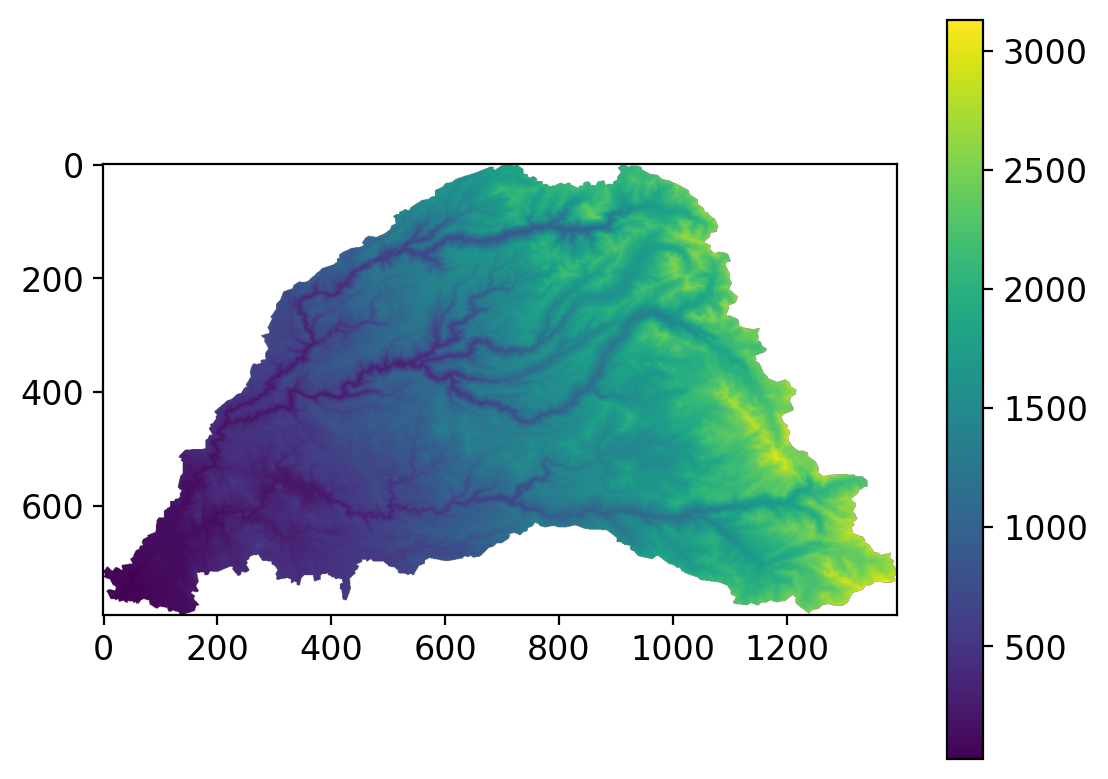

In [ ]:
im = plt.imshow(array)
plt.colorbar(im)

In [ ]:
# export deficit information for each basin
import time
t = time.time()
scale = 100
DpixDict = {}
for i in range(1):#,len(gages.STAID.values)):
    if i==23:
      continue
    key = gages.STAID.values[i]
    if key not in list(DpixDict.keys())[:]:
      # continue
      print(i,key)
      dates = []
      Dpixelmonth = []
      Dpixarrays = []
      id = key
      for yr in range(ystart_all+1,ystop_all):
        print(yr)
        for m in [10,11,12,1,2,3,4,5,6,7,8,9]:
          if m>=10:
            yy = yr
            mm = str(m)
          else:
            yy = yr+1
            mm = '0'+str(m)
          if m==12:
            dates.append(pd.to_datetime(str(m)+'-31-'+str(yy)))
          else:
            dates.append(pd.to_datetime(str(m+1)+'-1-'+str(yy))-datetime.timedelta(1))
          Dpix = Dasset.select('D_'+str(yy)+mm+'01')
          Dpix1 = Dpix.reduceRegion(geometry = geos[i],reducer = ee.Reducer.mean()).getInfo()['D_'+str(yy)+mm+'01']
          Dpixelmonth.append(Dpix1)
          array = geemap.ee_to_numpy(ee_object = Dpix.clip(geos[i]), region = geos[i],
                      scale = scale, )
          arraymask = geemap.ee_to_numpy(ee_object = Dpix.clip(geos[i]).mask(),
                                        region = geos[i],scale=scale)
          mask_bool = (arraymask>0)
          array = np.where(mask_bool,array,np.nan)

          Dpixarrays.append(array)
      DpixDict[key] = pd.DataFrame.from_dict({'date':dates,
                                              'Dpixel':Dpixelmonth,
                                              'DpixArray':Dpixarrays}).set_index('date')
    # print((time.time()-t)/60)
    # for key in DpixDict.keys():
      DD = DpixDict[key]
      joblib.dump(DD,
              str(gages.STAID.values[i])+'_Dpix_SWANN.joblib', compress=('lzma',3))
      # DD.Dpixel.plot()
      # DD.to_csv(str(key)+'_Dpix.csv')

24 TRF
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022


In [ ]:
# export streamflow information for each basin
import time
t = time.time()
DpixDict = {}
for i in range(22,len(gages.STAID.values)):
    if i==23:
      continue
    key = gages.STAID.values[i]
    if key not in list(DpixDict.keys())[:]:
      # continue
      print(i,key)
      dates = []
      Dpixelmonth = []
      Dpixarrays = []
      id = key
      for yr in range(ystart_all+1,ystop_all):
        print(yr)
        for m in [10,11,12,1,2,3,4,5,6,7,8,9]:
          if m>=10:
            yy = yr
            mm = str(m)
          else:
            yy = yr+1
            mm = '0'+str(m)
          if m==12:
            dates.append(pd.to_datetime(str(m)+'-31-'+str(yy)))
          else:
            dates.append(pd.to_datetime(str(m+1)+'-1-'+str(yy))-datetime.timedelta(1))
          Dpix = Qasset.select('D_'+str(yy)+mm+'01')
          Dpix1 = Dpix.reduceRegion(geometry = geos[i],reducer = ee.Reducer.mean()).getInfo()['D_'+str(yy)+mm+'01']
          Dpixelmonth.append(Dpix1)
          array = geemap.ee_to_numpy(ee_object = Dpix.clip(geos[i]), region = geos[i],
                      scale = 100, )
          arraymask = geemap.ee_to_numpy(ee_object = Dpix.clip(geos[i]).mask(),
                                        region = geos[i],scale=100)
          mask_bool = (arraymask>0)
          array = np.where(mask_bool,array,np.nan)

          Dpixarrays.append(array)
      DpixDict[key] = pd.DataFrame.from_dict({'date':dates,
                                              'Qpixel':Dpixelmonth,
                                              'QpixArray':Dpixarrays}).set_index('date')
    # print((time.time()-t)/60)
    # for key in DpixDict.keys():
      DD = DpixDict[key]
      joblib.dump(DD,
              str(gages.STAID.values[i])+'_Qpix_SWANN.joblib', compress=('lzma',3))
      # from google.colab import files
      # files.download(str(gage_info.STAID.values[i])+'_Qpix_SWANN.joblib')
      # DD.Dpixel.plot()
      # DD.to_csv(str(key)+'_Dpix.csv')

22 SIS
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
24 TRF
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022


In [ ]:
joblib.dump(DD,
              str(gages.STAID.values[i])+'_Qpix_SWANN.joblib', compress=('lzma',3))

['AMF_Qpix_SWANN.joblib']

In [ ]:
joblib.duamp(pd.DataFrame.from_dict({'date':dates,
                                    'Qarray':Qarrays}),
            str(gage_info.STAID.values[i])+'_Qpix.joblib', compress=('lzma',3))

In [ ]:
datas = [np.nanmean(Qarrays[i]) for i in range(len(Qarrays))]

plt.plot(datas)

In [ ]:
i = 0
yr = 2001
m = '10'
id = gage_info.STAID.values[i]
# imtestD = ee.Image('projects/ee-danalapides/assets/'+str(id)+'_Doct_'+str(yr)+'_'+m)
# imtestP = ee.Image('projects/ee-danalapides/assets/'+str(id)+'_P_'+str(yr))
# imtestET = ee.Image('projects/ee-danalapides/assets/'+str(id)+'_ET_'+str(yr))

im = ee.Image('projects/ee-danalapides/assets/D_SWANN')

# y = 2023
# m = '11'
# st = ee.Date(str(y)+'-'+m+'-01')
# end = ee.Date(str(y+1)+'-'+str(int(m)+1)+'-1')
# if m=='12':
#   end = ee.Date(str(y+1)+'-'+str(int(m))+'-31')
# im = Ppixel.filterDate(st, end).reduce(ee.Reducer.sum())

Map = geemap.Map()
Map.centerObject(geos[i], 8)
vis_params_D = {'min':0,
              'max':700
              }
vis_params = {'min':0,
              'max':1000}
# Map.addLayer(imtestD, vis_params_D, 'Deficit', )
Map.addLayer(im, vis_params, 'Q', )
# Map.addLayer(imtestP, vis_params, 'P')
# Map.addLayer(imtestET, vis_params, 'ETsum', )
# Map.add_gdf(gage_info[i:i+1], layer_name='basins')
Map

Map(center=[38.93718217695263, -120.58767096163336], controls=(WidgetControl(options=['position', 'transparent…

In [ ]:
import joblib
for i in range(len(gage_info)):
  # if i<7:
  #   continue
  print(i+1,'of',len(gage_info))
  id = gage_info.STAID.values[i]
  print(id)
  Dpixelvals = []
  DpixArrayvals = []
  dates = []
  for y in range(2001,2024):
    print(y)
    for m in range(1,13):
      if (y==2000)&(m<10):
        continue
      if (y==2023)&(m>9):
        continue
      if m==1:
        mm = '01'
      else:
        mm = str(m)
      imtestD = ee.Image('projects/ee-danalapides/assets/'+str(id)+'_Q_'+str(y)+'-'+mm+'-01')
      Dpixelvals.append(imtestD.reduceRegion(geometry = geos[i],reducer = ee.Reducer.mean()).getInfo()['Q_sum'])

      array = geemap.ee_to_numpy(ee_object = imtestD.clip(geos[i]), region = geos[i],
                   scale = 100, )
      arraymask = geemap.ee_to_numpy(ee_object = imtestD.clip(geos[i]).mask(),
                                    region = geos[i],scale=100)
      mask_bool = (arraymask>0)
      array = np.where(mask_bool,array,np.nan)

      DpixArrayvals.append(array)
      dates.append(str(y)+'-'+str(m+1)+'-01')
  Qpixdata = pd.DataFrame({'Qpixel':Dpixelvals,'QpixArray':DpixArrayvals},index=dates)
  joblib.dump(Qpixdata, str(id)+'_Qpix.joblib', compress=('lzma',3))

In [ ]:
i=0
def reduce_image(img):
    stats = img.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=geos[i],
        scale=100,
        bestEffort=True
    )
    return ee.Feature(None, stats).set('system:time_start', img.get('system:time_start'))

reduced = Q_collection.map(reduce_image)  # returns a FeatureCollectionQ_collection.reduce(reducer = ee.Reducer.mean())#reduceRegion(geometry=geos[0],reducer=ee.Reducer.mean()))
r = reduced.getInfo()

In [ ]:
import joblib
for i in range(len(gage_info)):
  if i==23:
    continue
  # if i==1:
  #   continue
  geo = geos[i]
  print(i+1,'of',len(gage_info))
  id = gages.STAID.values[i]
  print(id)
  Parrays = []
  ETarrays = []
  dates = []
  for y in range(2001,2024):
      print(y)
    # for m in range(1,13):

      # if y==2001 and m<10:
      #   continue
      # if y==2023 and m>9:
      #   continue
      # print(y,m)
      start, stop = str(y-1)+'-10-01',str(y)+'-10-01'
      imtest = ee.ImageCollection("OREGONSTATE/PRISM/AN81m") \
        .filterBounds(geo) \
        .filterDate(start, stop) \
        .select('ppt').sum()
      # imtest = ee.Image('projects/ee-danalapides/assets/'+str(id)+'_P_wy'+str(y))
      # imtestET = ee.Image('projects/ee-danalapides/assets/'+str(id)+'_ET_wy'+str(y))

      dataset = ee.ImageCollection("CAS/IGSNRR/PML/V2_v018").filterBounds(geo).filterDate(start,stop)

      # mapper for getting single ET raster for each timestep
      def sumpml(image, ):
        # ET bands into one band
        temp = image.select('Es').add(image.select('Ec')).add(image.select('Ei'))#.multiply(scale)

        #get the first band of this new temporary image, rename it to 'ET',
        #reproject it, and then multiply by multiplier
        temp = temp.select([0], ['ET']).reproject(
            crs='EPSG:4326',scale=scale
            ).multiply(8.0)#.multiply(scale)

        #temp should now be total ET in mm over the time window between images
        #assign the datetime stamp and the index from the original image
        temp = temp.set('system:time_start', image.get('system:time_start'))
        temp = temp.set('system:index', image.get('system:index'))
        return temp

      #now, actually map the pml image collection w/ this function,
      # in order to make a new combined ET image collection
      imtestET = ee.ImageCollection(dataset.map(sumpml).select('ET')).filter(ee.Filter.date(start, stop)).sum()

      array = geemap.ee_to_numpy(ee_object = imtest.clip(geos[i]), region = geos[i],
                    scale = 100, )
      arraymask = geemap.ee_to_numpy(ee_object = imtest.clip(geos[i]).mask(),
                                    region = geos[i],scale=100)
      mask_bool = (arraymask>0)
      array = np.where(mask_bool,array,np.nan)
      Parrays.append(array)

      arrayET = geemap.ee_to_numpy(ee_object = imtestET.clip(geos[i]), region = geos[i],
                    scale = 100, )
      arraymask = geemap.ee_to_numpy(ee_object = imtestET.clip(geos[i]).mask(),
                                    region = geos[i],scale=100)
      mask_bool = (arraymask>0)
      arrayET = np.where(mask_bool,arrayET,np.nan)
      ETarrays.append(arrayET)
      # if m<12:
      #   mm = m+1
      #   yy = y
      # else:
      #   mm = 1
      #   yy = y+1

      dd = str((y))
      dates.append(dd)

  pixData = pd.DataFrame({'ETarray':ETarrays,'Parray':Parrays},index=dates)
  # Dpixdata.to_pickle(str(id)+'_Dpix.pkl.bz2', compression="bz2")
  joblib.dump(pixData, str(id)+'_arrays_wy.joblib', compress=('lzma',3))

1 of 25
AMF
2001
2002
2003
2004
2005
2006


2007
2008
2009
2010


2011
2012
2013
2014
2015
2016
2017
2018


2019
2020
2021
2022
2023


2 of 25
MSS
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010


2011


2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023
3 of 25
SDT
2001
2002
2003


2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023
4 of 25
TNL
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023
5 of 25
PSH
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023
6 of 25
YRS
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023
7 of 25
TKT
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023
8 of 25
WFC
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023
9 of 25
CSN
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023
10 of 25
EFC
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023
11 of 25
M

In [ ]:
pixData.index

In [ ]:
import joblib
for i in range(1,2):#len(gage_info)):
  # if i<7:
  #   continue
  print(i+1,'of',len(gage_info))
  id = gage_info.STAID.values[i]
  print(id)
  Parrays = []
  ETarrays = []
  dates = []
  for y in range(2001,2024):
    print(y)
    imtest = ee.Image('projects/ee-danalapides/assets/'+str(id)+'_P_'+str(y))
    imtestET = ee.Image('projects/ee-danalapides/assets/'+str(id)+'_ET_'+str(y))

    array = geemap.ee_to_numpy(ee_object = imtest.clip(geos[i]), region = geos[i],
                  scale = 100, )
    arraymask = geemap.ee_to_numpy(ee_object = imtest.clip(geos[i]).mask(),
                                  region = geos[i],scale=100)
    mask_bool = (arraymask>0)
    array = np.where(mask_bool,array,np.nan)
    Parrays.append(array)

    arrayET = geemap.ee_to_numpy(ee_object = imtestET.clip(geos[i]), region = geos[i],
                  scale = 100, )
    arraymask = geemap.ee_to_numpy(ee_object = imtestET.clip(geos[i]).mask(),
                                  region = geos[i],scale=100)
    mask_bool = (arraymask>0)
    arrayET = np.where(mask_bool,arrayET,np.nan)
    ETarrays.append(arrayET)
    dates.append(str(y))
  pixData = pd.DataFrame({'ETarray':ETarrays,'Parray':Parrays},index=dates)
  # Dpixdata.to_pickle(str(id)+'_Dpix.pkl.bz2', compression="bz2")
  joblib.dump(pixData, str(id)+'_arrays.joblib', compress=('lzma',3))

In [ ]:
EDpixdata = pd.DataFrame({'Dpixel':Dpixelvals[:],},index=dates[:])
  # Dpixdata.to_pickle(str(id)+'_Dpix.pkl.bz2', compression="bz2")
joblib.dump(Dpixdata, str(id)+'_Dpix.joblib', compress=('lzma',3))
d = import_Dpix(gages.STAID.values[1])
d.Dpixel.plot()

# Download and calculate basin scale using GEE

## Calculate Deficit at basin scale

In [ ]:
# # for each study basin, get basin-average ET, P
# swedata_all = pd.read_csv('https://raw.github.com/lapidesd/deficit_aggregation/main/Data/SWANN_SWE_deficit_agg.csv')
# swedata_all['date'] = pd.to_datetime(swedata_all.date)
# swedata_all = swedata_all.set_index('date')


data = {}
for i,geo in enumerate(geos[:]):
  if i==23:
    continue
  # code adapted from David Dralle
  # Flux is stored as 100*mm/day, and duration between samples is 8 days
  multiplier = 8.0
  dataset = ee.ImageCollection("CAS/IGSNRR/PML/V2_v018");
  # scale = 0.01

  # mapper for getting single ET raster for each timestep
  def sumpml(image):
    # ET bands into one band
    temp = image.select('Es').add(image.select('Ec')).add(image.select('Ei'))#.multiply(scale)

    #get the first band of this new temporary image, rename it to 'ET',
    #reproject it, and then multiply by multiplier
    temp = temp.select([0], ['ET']).reproject(
        crs='EPSG:4326',scale = scale
        ).multiply(multiplier)

    #temp should now be total ET in mm over the time window between images
    #assign the datetime stamp and the index from the original image
    temp = temp.set('system:time_start', image.get('system:time_start'))
    temp = temp.set('system:index', image.get('system:index'))
    return temp

  #now, actually map the pml image collection w/ this function,
  # in order to make a new combined ET image collection
  et = ee.ImageCollection(dataset.map(sumpml).select('ET')).filter(ee.Filter.date(start_all, stop_all))
  et = et.toBands()
  ft = et.reduceRegion(ee.Reducer.mean(), geo, scale, maxPixels = 673307936989480)
  vals = ft.getInfo()
  dates = pd.to_datetime(['-'.join(item.split('_')[4:-1]) for item in list(vals)])
  etvals = [item for item in vals.values()]
  etdf = pd.DataFrame({'ET':etvals},index=dates)

  # first linearly interpolate to daily and then resample to monthly
  etdf = etdf.resample('M').sum()

  # get P
  dataset = ee.ImageCollection("OREGONSTATE/PRISM/AN81m").filter(ee.Filter.date(str(ystart_all)+'-10-01',
                                                                                str(ystop_all)+'-10-01'))
  ppt = dataset.select('ppt').toBands()
  ft = ppt.reduceRegion(ee.Reducer.mean(), geo, scale)
  vals = ft.getInfo()
  dates = pd.to_datetime([item.split('_')[0] for item in list(vals)],format='%Y%m')
  pptvals = [item for item in vals.values()]
  pptdf = pd.DataFrame({'P':pptvals},index=dates).resample('M').sum()

  # get SWE
  stop1 = '2011-10-01'
  start1 = '2011-09-29'
  stop = str(ystop_all)+'-10-01'
  # swe = ee.ImageCollection("NASA/ORNL/DAYMET_V4").filter(ee.Filter.date(str(ystart_all)+'-10-01',stop1))
  # swe = ee.ImageCollection('projects/earthengine-legacy/assets/projects/climate-engine/snodas/daily').filterDate(str(ystart_all)+'-10-01',stop1)
  swe = SWANN_SWE.filter(ee.Filter.date(str(ystart_all)+'-10-01',stop1))
  swe = swe.select('SWE').toBands()
  # swe = swepixel.toBands()
  ft = swe.reduceRegion(ee.Reducer.mean(), geo, scale)
  vals = ft.getInfo()
  dates = pd.to_datetime([item.split('_')[0] for item in list(vals)],format='%Y%m%d')
  swevals = [item for item in vals.values()]
  swedf = pd.DataFrame({'SWE':swevals},index=dates)#.resample('M').sum()
  # swe1 = ee.ImageCollection("NASA/ORNL/DAYMET_V4").filter(ee.Filter.date(start1,stop))
  # swe1 = ee.ImageCollection('projects/earthengine-legacy/assets/projects/climate-engine/snodas/daily').filterDate(start1,stop)
  swe1 = SWANN_SWE.filterDate(start1,stop)
  swe1 = swe1.select('SWE').toBands()
  # swe = swepixel.toBands()
  ft = swe1.reduceRegion(ee.Reducer.mean(), geo, scale)
  vals = ft.getInfo()
  dates = pd.to_datetime([item.split('_')[0] for item in list(vals)],format='%Y%m%d')
  swevals1 = [item for item in vals.values()]
  swedf1 = pd.DataFrame({'SWE':swevals1},index=dates)#.resample('M').sum()
  swedf = pd.concat([swedf,swedf1]).resample('D').first().interpolate(limit=5).fillna(0)
  swedf = swedf.diff().resample('M').sum()
  # try:
  #   swedf = swedata_all[[gages.STAID.values[i]]].rename(columns={gages.STAID.values[i]:'SWE'})
  #   swedf = swedf.diff().resample('M').sum()
  # except:
  #   print(i,gages.STAID.values[i])


  # Combine
  df = pd.concat([etdf, pptdf,swedf],axis=1)
  # df['W'] = df[['P','ET']].min(axis=1)
  df['wy'] = [item.year if item.month<10 else item.year+1 for item in df.index]
  df['sumP'] = df.groupby('wy')['P'].cumsum()

  data[names[i]] = df



In [ ]:
# Wang-Erlandsson storage deficit mass balance approach
# including snow from SNODAS

for site in gages.STAID.values:
  if site==gages.STAID.values[23]:
    continue
  gageid = gages[gages.STAID==site].STAID.values[0]
  if 'SWE' in data[site].columns:

    temp = data[site]
    try:
      col = int(gageid)
    except:
      col = gageid


    # calculate total water inputs as P (take out snowfall, add in snowmelt)
    P_adj = temp.P-temp.SWE

    df = temp
    df['P_adj'] = np.where((temp.SWE>temp.P),temp.P, P_adj)
    deficit = [0]
    counter = 0
    gage = gageid

    # deficit calculation
    for idx,row in df.fillna(0).iterrows():
      A = row.ET - row.P_adj
      next = np.max([0, deficit[counter] + A])
      deficit.append(next)
      counter = counter + 1

    df['D'] = deficit[1:]

    data[site] = df

In [ ]:
df

,ET,P,SWE,wy,sumP,P_adj,D
2000-10-31,46.127080,159.001121,0.000000,2001,159.001121,159.001121,0.000000
2000-11-30,15.852446,58.430870,-1.521837,2001,217.431991,59.952706,0.000000
2000-12-31,13.446847,98.205644,13.219460,2001,315.637635,84.986184,0.000000
2001-01-31,13.261776,148.084251,67.568289,2001,463.721886,80.515962,0.000000
2001-02-28,20.377606,261.264718,128.657386,2001,724.986603,132.607331,0.000000
...,...,...,...,...,...,...,...
2023-06-30,91.188704,23.348985,-224.157193,2023,2084.387650,247.506177,0.000000
2023-07-31,94.257774,0.000000,-38.871305,2023,2084.387650,38.871305,55.386468
2023-08-31,86.113590,18.327406,0.000000,2023,2102.715056,18.327406,123.172653
2023-09-30,71.777771,30.547899,0.000000,2023,2133.262955,30.547899,164.402524


In [ ]:
for key in data.keys():
  d = data[key]
  d.dropna().to_csv(str(key)+'_data_SWANN.csv')
d

,ET,P,SWE,wy,sumP,P_adj,D
2000-10-31,37.774940,63.353965,0.000000,2001,63.353965,63.353965,0.000000
2000-11-30,10.803934,39.950253,7.923679,2001,103.304218,32.026575,0.000000
2000-12-31,9.268683,41.471769,22.216222,2001,144.775987,19.255547,0.000000
2001-01-31,9.724331,62.834259,52.972494,2001,207.610246,9.861764,0.000000
2001-02-28,17.085049,121.555479,101.498528,2001,329.165724,20.056951,0.000000
...,...,...,...,...,...,...,...
2023-06-30,86.919110,45.559303,-262.206863,2023,1328.662719,307.766166,0.000000
2023-07-31,83.041659,0.033475,-27.655828,2023,1328.696194,27.689303,55.352356
2023-08-31,75.210066,31.961837,0.000000,2023,1360.658031,31.961837,98.600586
2023-09-30,60.700365,28.907461,0.000000,2023,1389.565492,28.907461,130.393490


In [ ]:
for key in data.keys():
  d = data[key]
  # d[['ET']].to_csv('ET_'+str(key)+'.csv')
  # d[['P']].to_csv('P_'+str(key)+'.csv')
  d[['SWE']].to_csv('Delta_SWE_SNODAS_'+str(key)+'.csv')

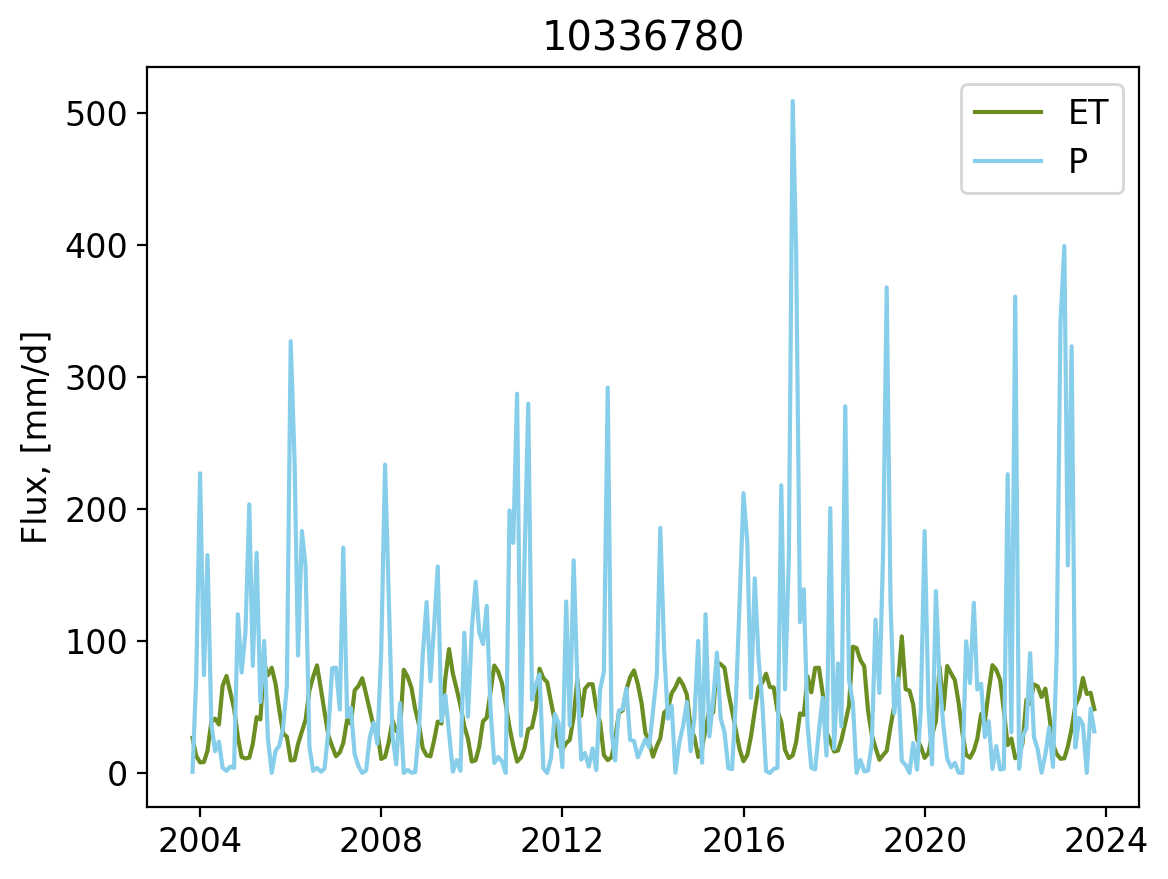

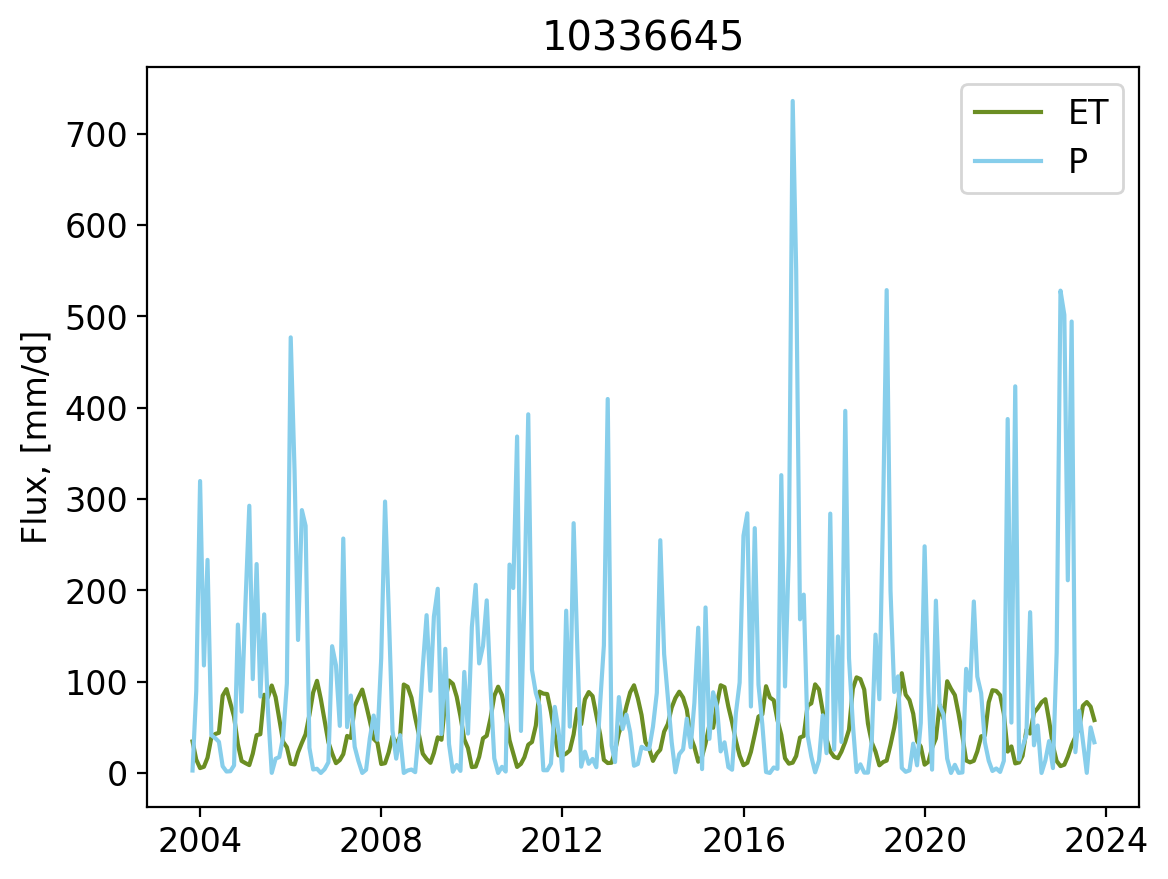

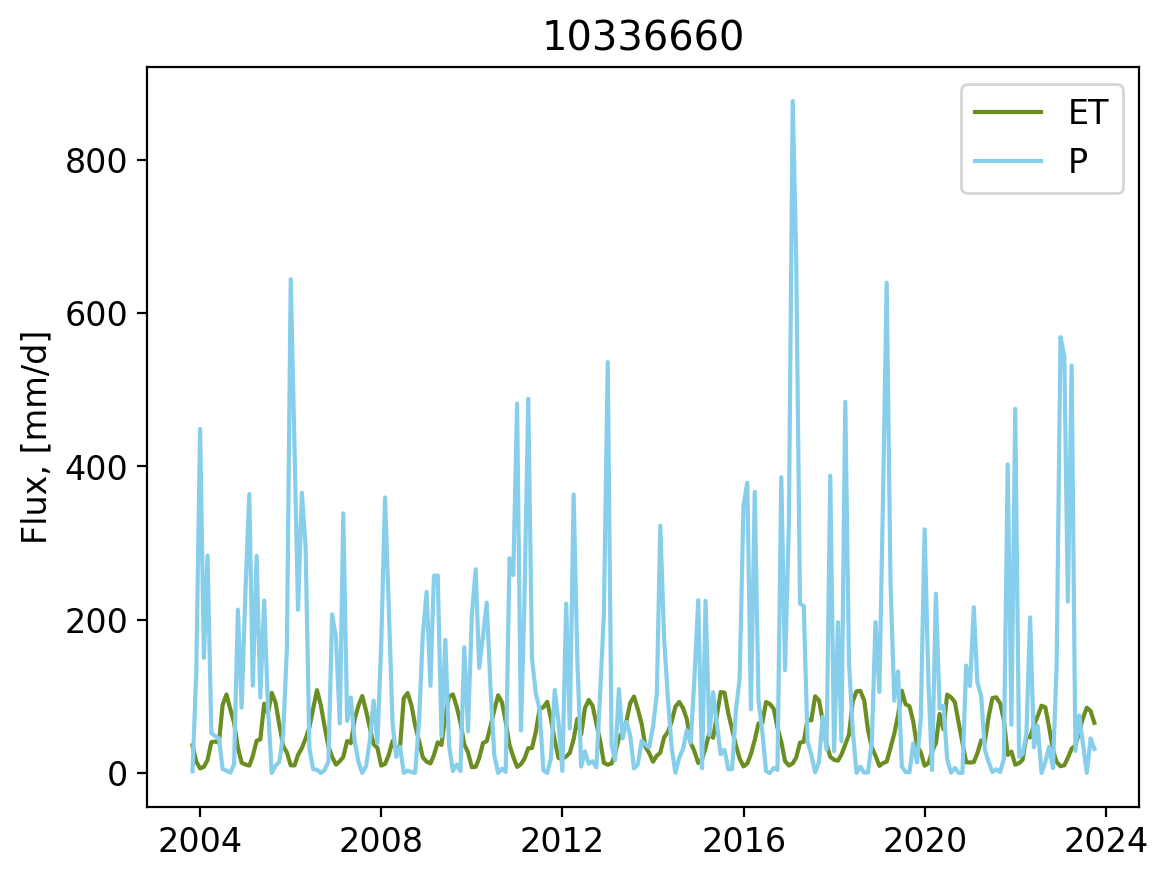

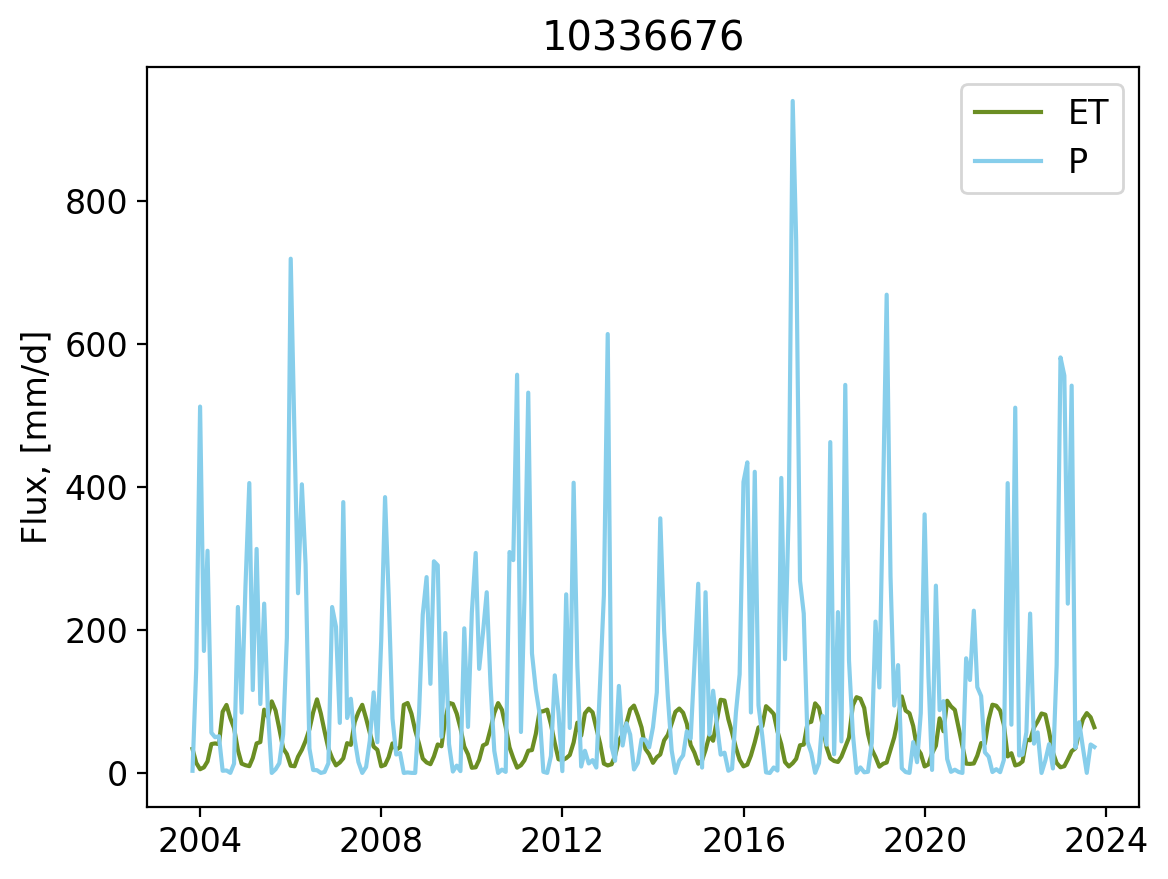

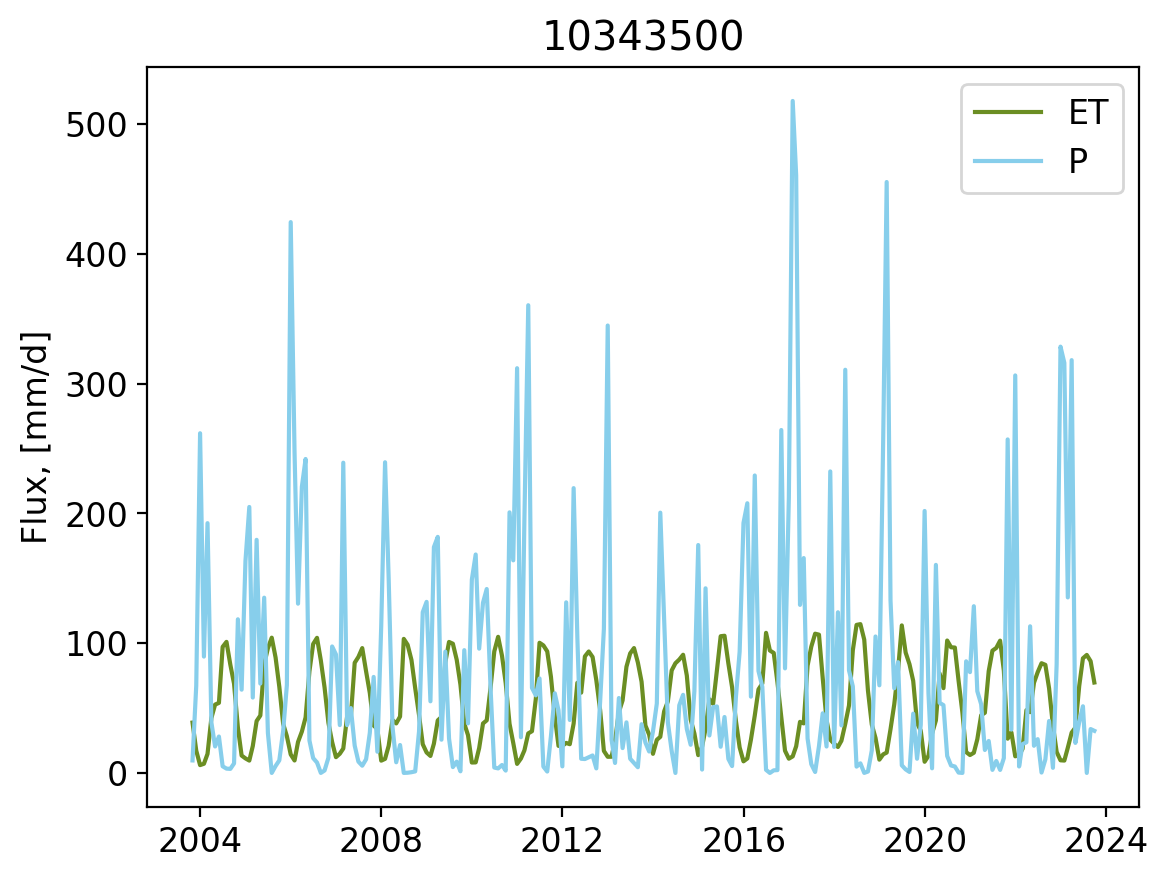

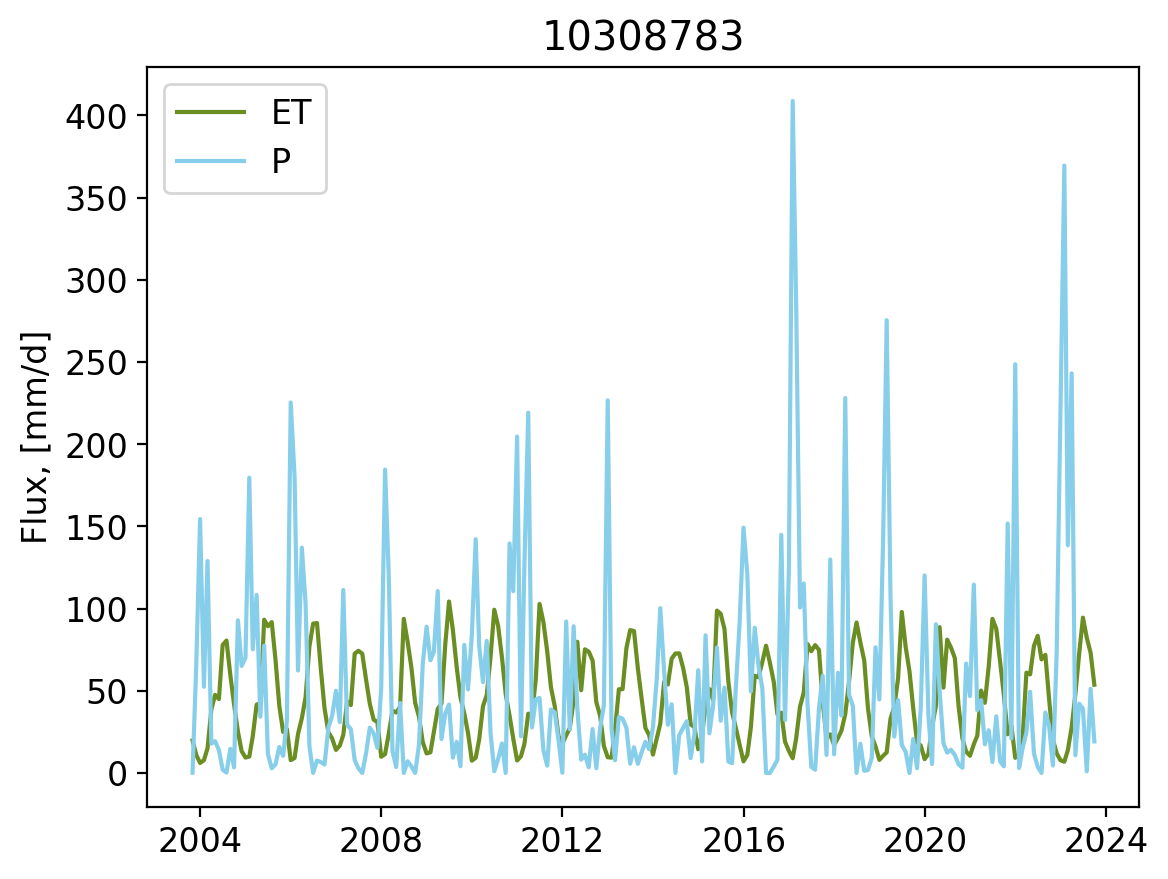

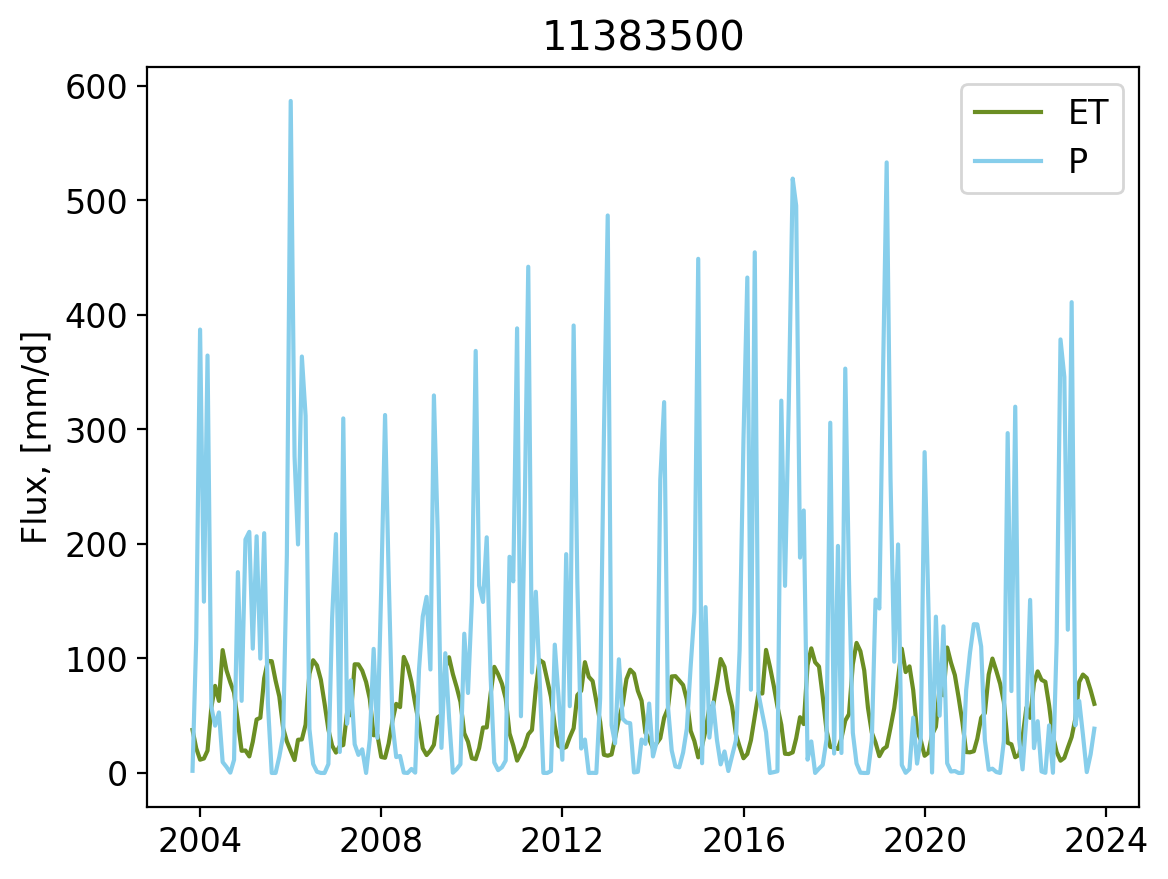

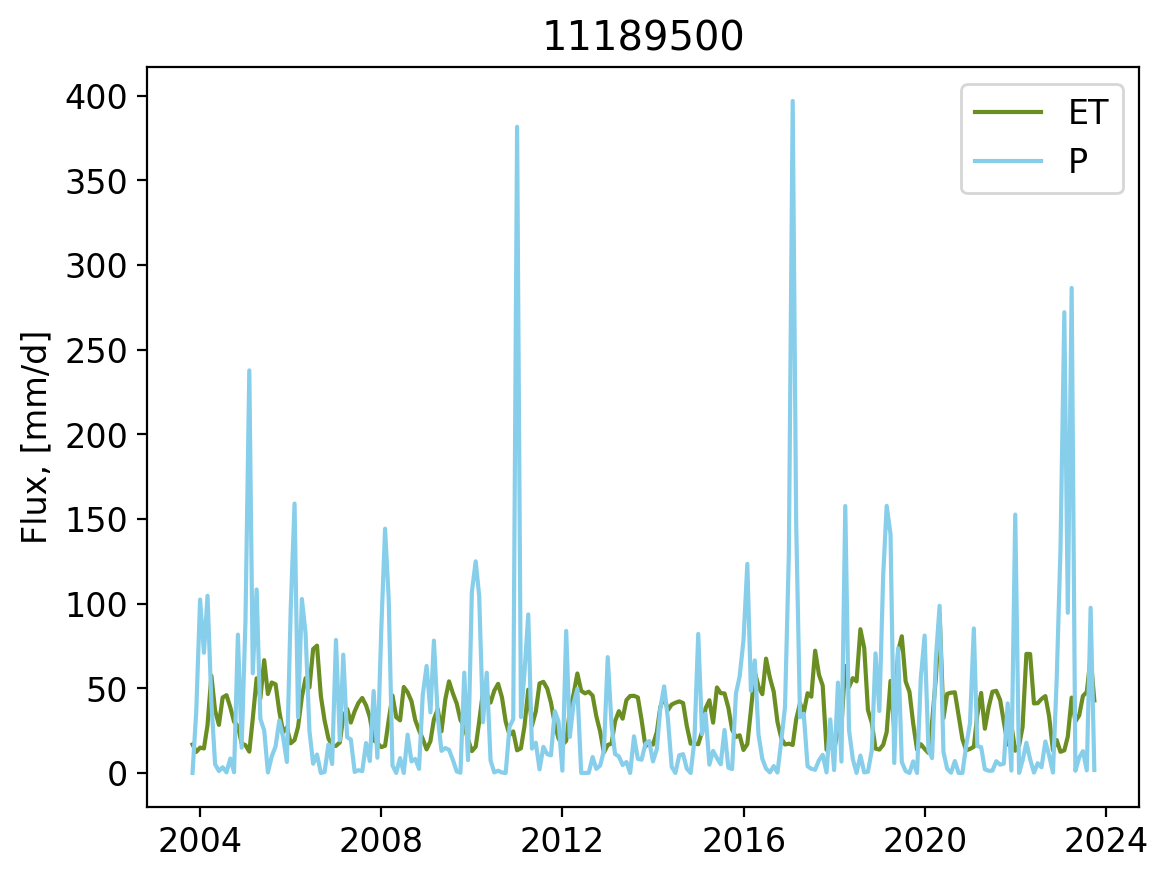

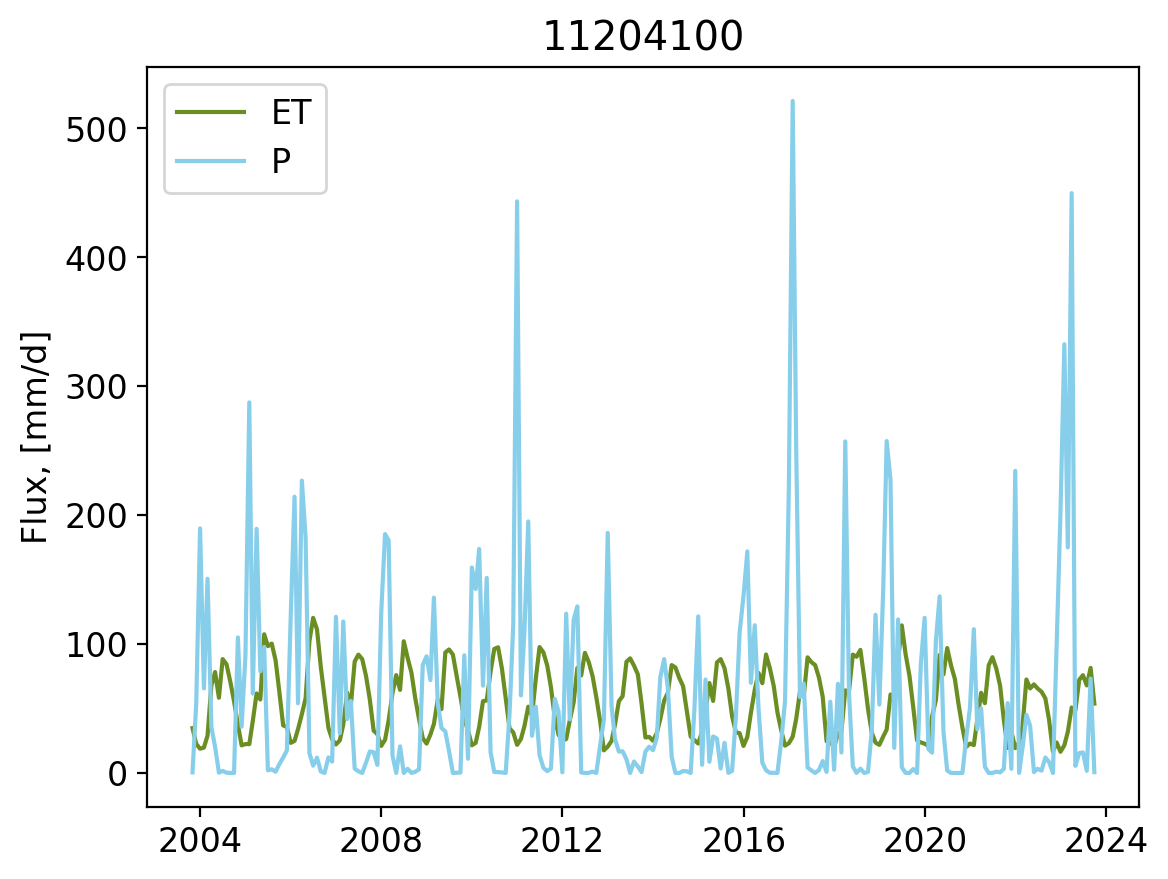

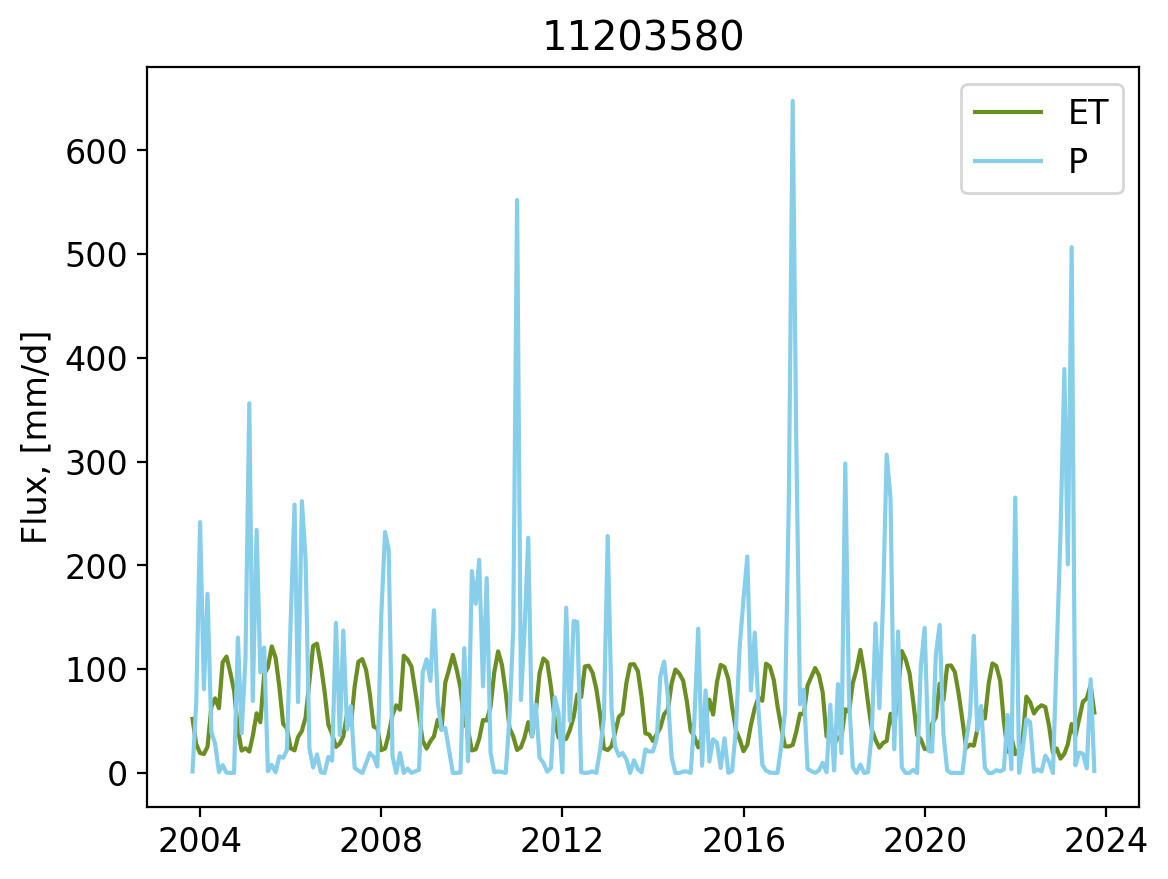

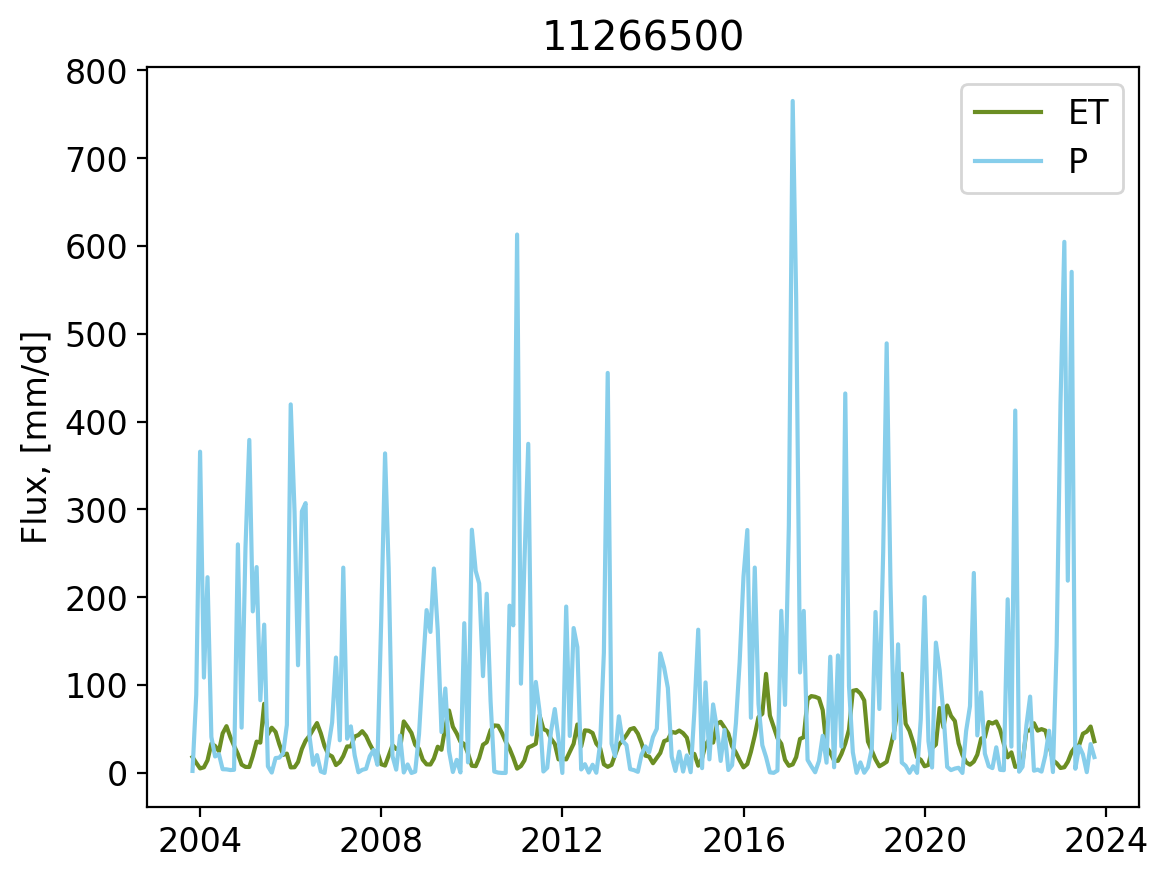

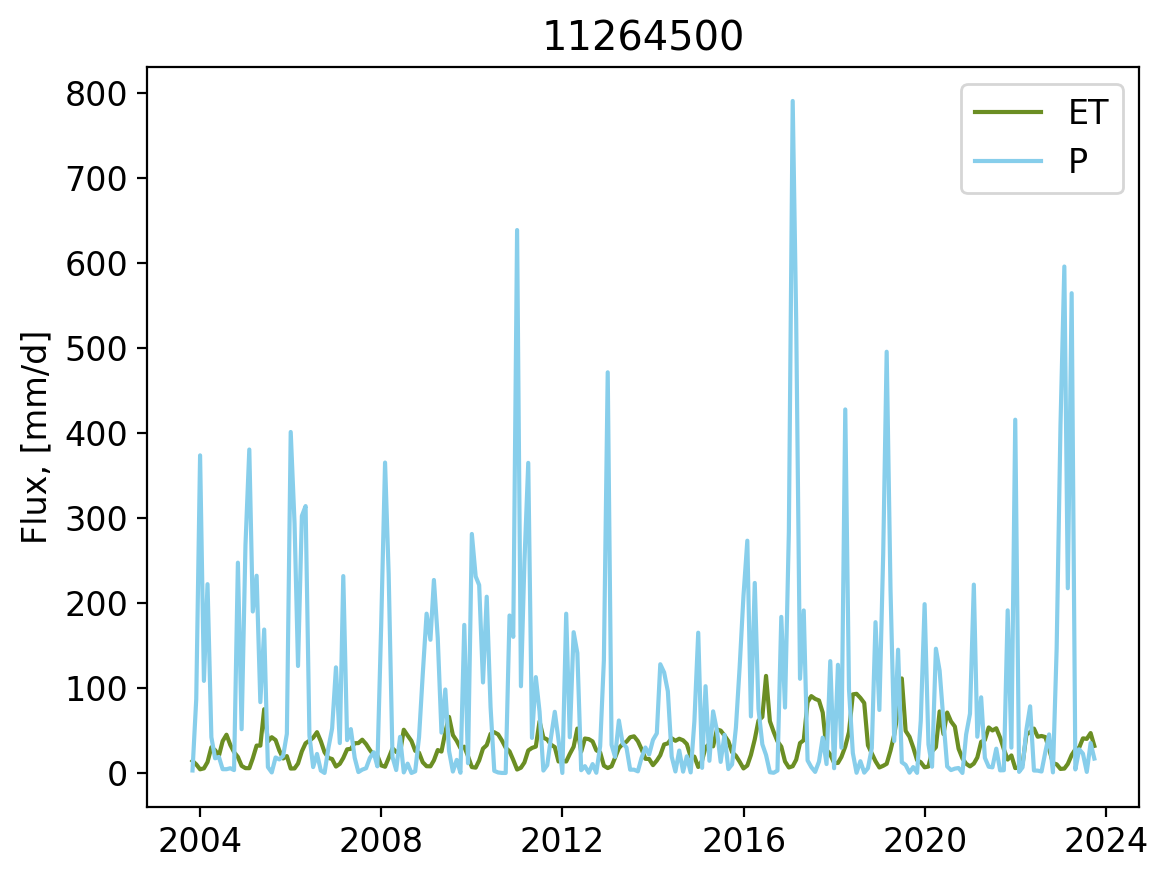

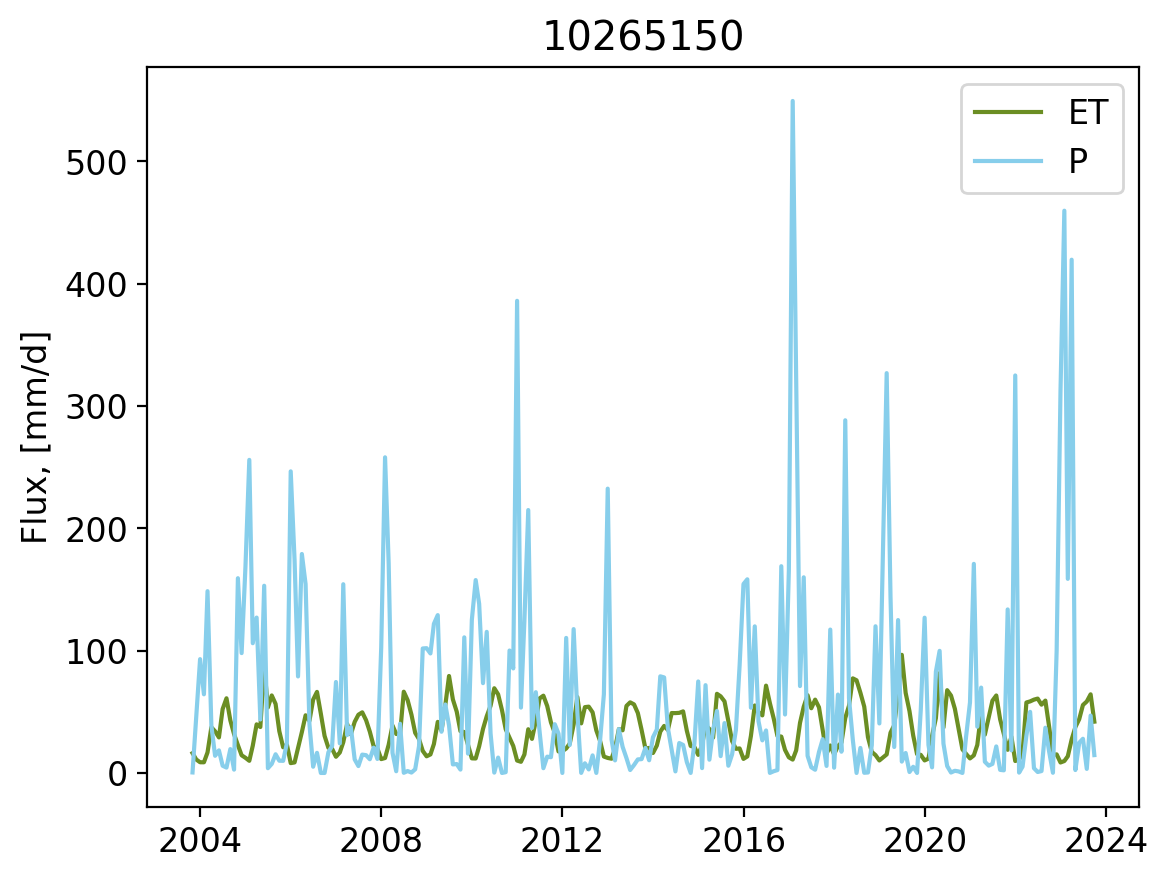

In [ ]:
for site in list(data.keys()):
  dsite = data[site].dropna()
  fig,ax = plt.subplots(1)
  ax.plot(dsite.index,dsite.ET,label='ET',c='olivedrab')
  ax.plot(dsite.index,dsite.P-dsite.SWE,label='P',c='skyblue')
  ax.set_title(site)
  ax.legend()
  ax.set_ylabel('Flux, [mm/d]')
  plt.show()
  # print(data[site].head())

## Calculate deficit from mass balance

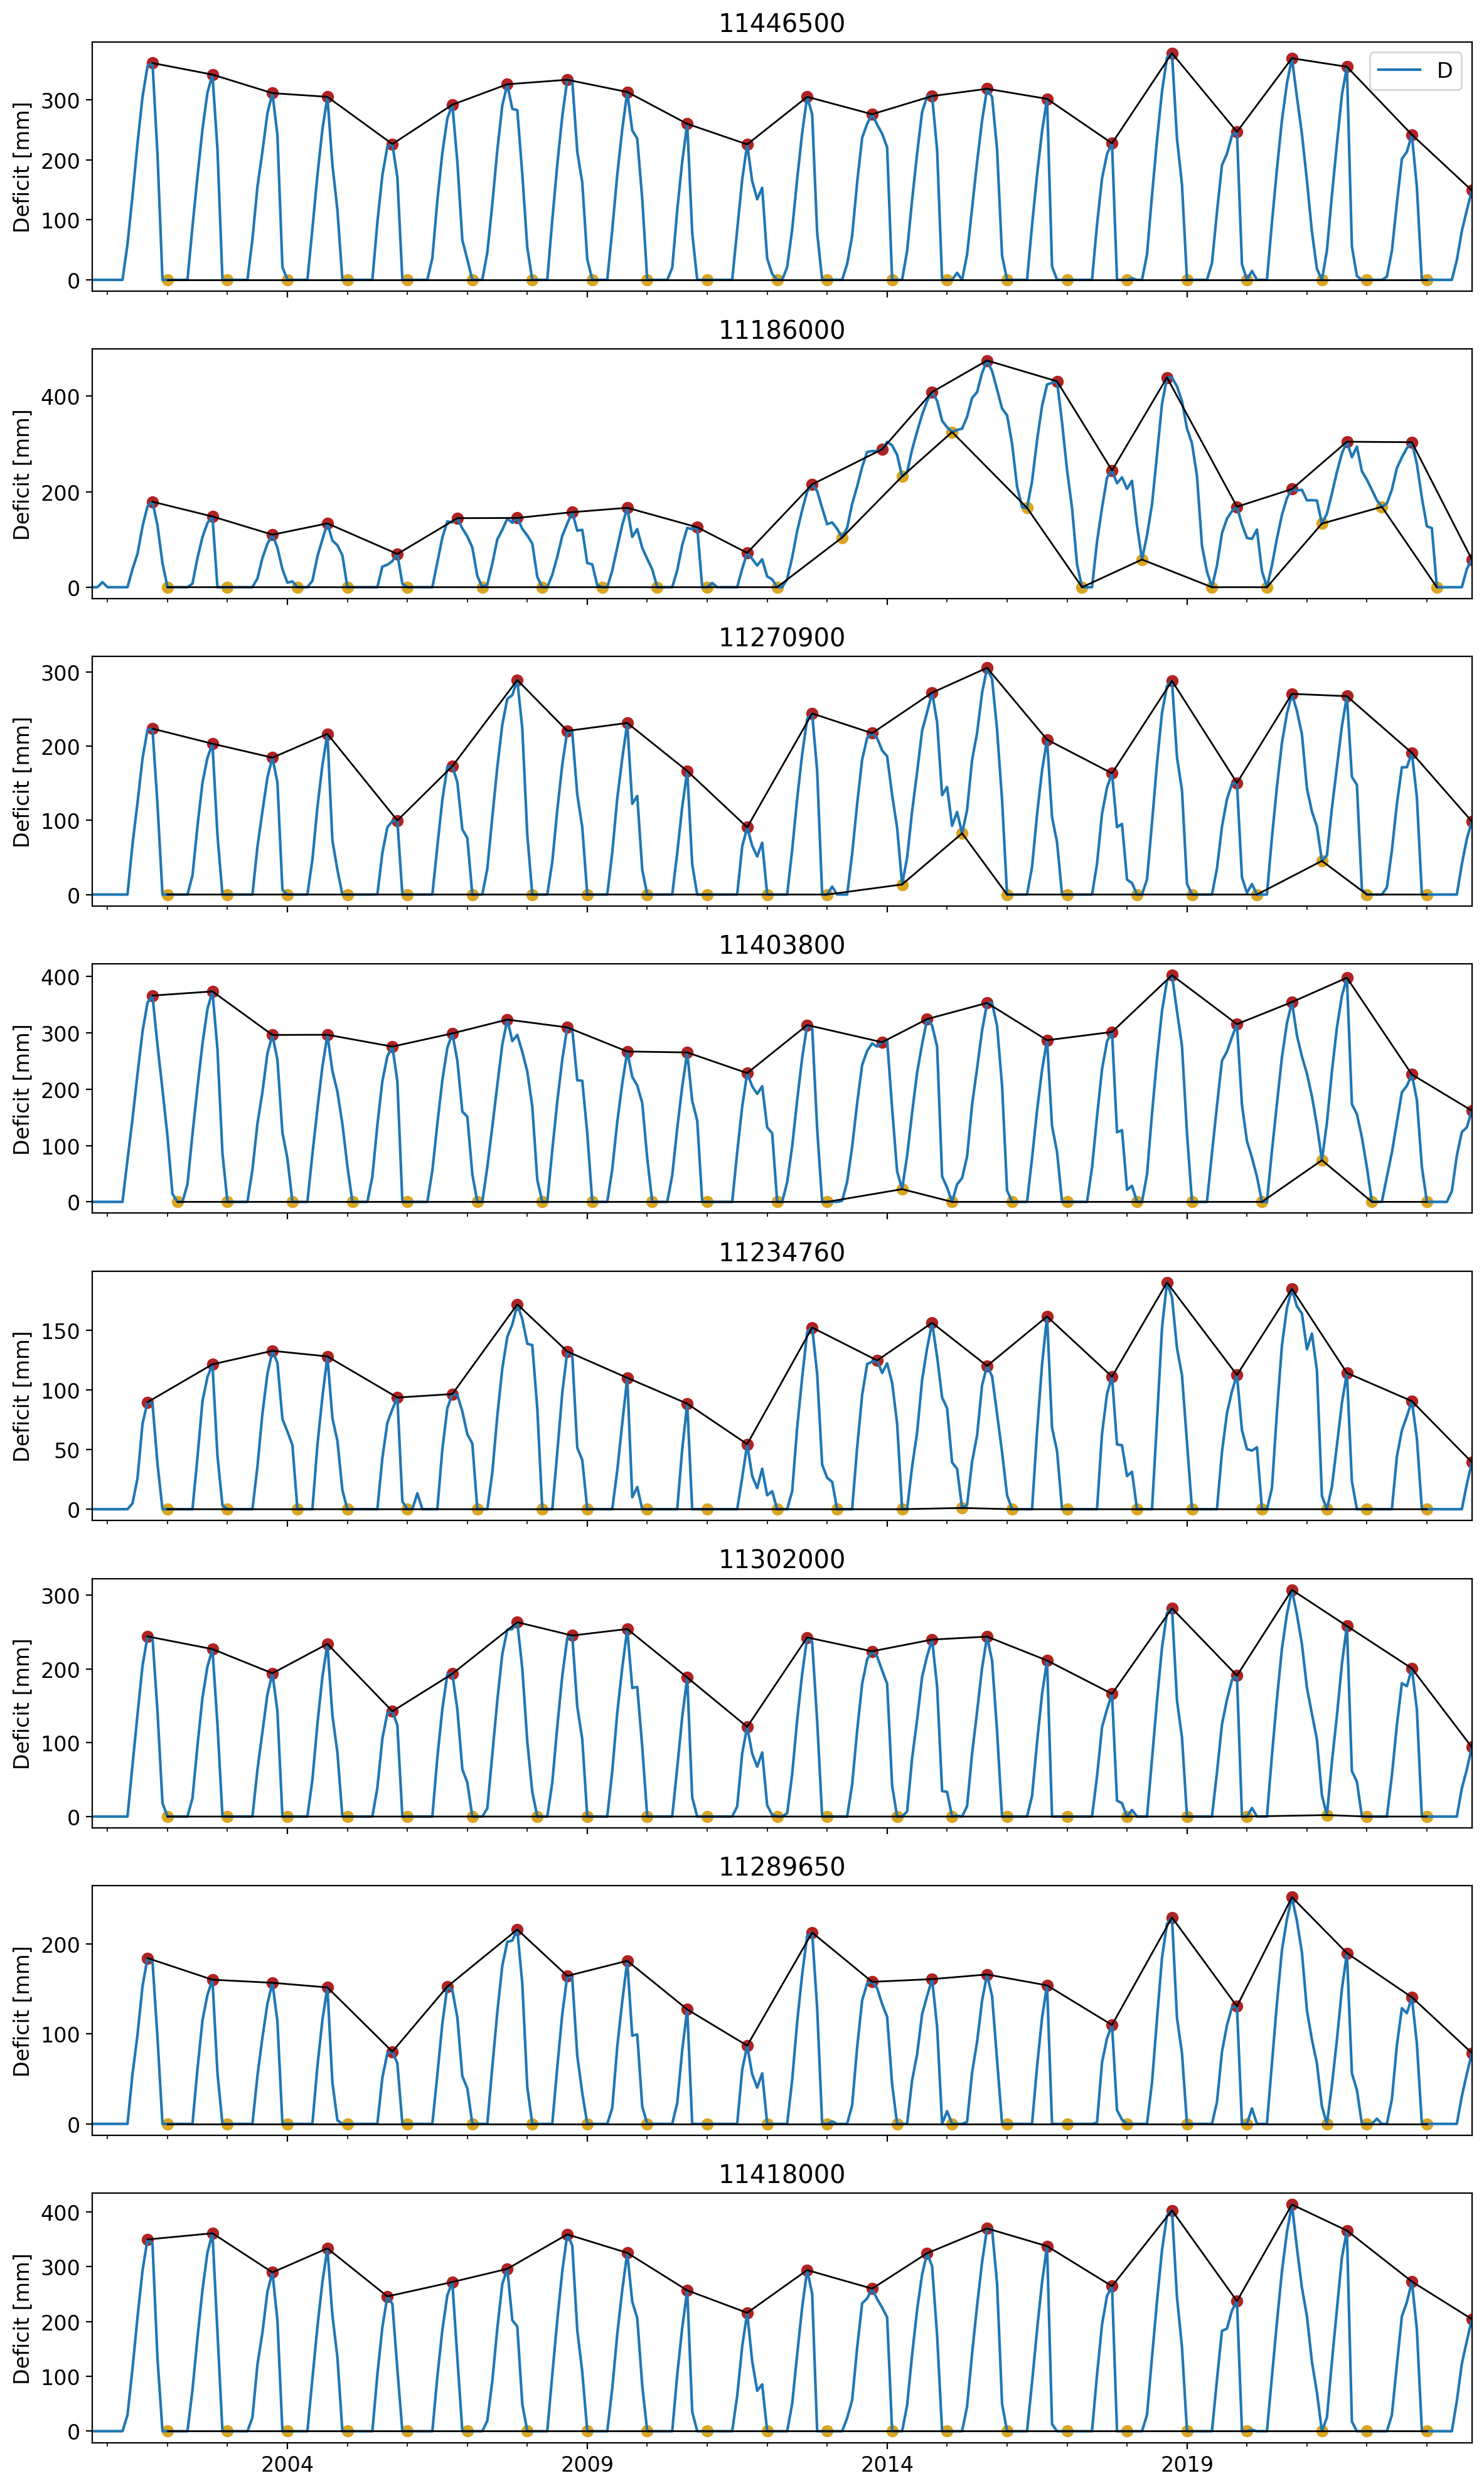

In [ ]:
# plot running deficit calculation at all sites

f,axs = plt.subplots(8,figsize=(12,20),sharex=True)

for i in range(len(gages)):
  ax = axs.flatten()[i]
  temp = data[gages.STAID.values[i]]
  temp.D.plot(ax=ax,label=None)

  if i==0:
    ax.legend()
  temp['wy_shift'] = temp.index.year+1
  maxDates = temp.loc[temp[temp.index.month.isin([8,9,10,11,12,])].groupby("wy_shift")["D"].idxmax()].iloc[1:]
  minDates = temp.loc[temp[temp.index.month.isin([1,2,3,4,5,6])].groupby("wy")["D"].idxmin()].iloc[1:]
  maxDates.D.plot(ax=ax,c='k',lw=1,label=None)
  minDates.D.plot(ax=ax,c='k',lw=1,label=None)
  ax.scatter(maxDates.index,maxDates.D,c='firebrick',label='Max. deficit')
  ax.scatter(minDates.index,minDates.D,c='goldenrod',label='Min. deficit')
  ax.set_title(gages.STAID.values[i])
  ax.set_ylabel('Deficit [mm]')
f.tight_layout()